<a href="https://colab.research.google.com/github/rossaedwards/main/blob/main/Vacuum_Impedance_Matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import matplotlib.pyplot as plt
import os
import json

def quick_save(filename):
    """Saves the current matplotlib figure to Google Drive."""
    path = '/content/drive/MyDrive/VIM_Figures'
    os.makedirs(path, exist_ok=True)
    plt.savefig(f"{path}/{filename}.png", bbox_inches='tight', dpi=300)
    print(f"Saved to Drive: {filename}.png")

def clean_notebook(notebook_path='/content/VIM.ipynb', output_path='/content/VIM_cleaned.ipynb'):
    """
    Lints the notebook by replacing invisible non-breaking spaces (\xa0)
    with regular spaces across all code cells.
    """
    if not os.path.exists(notebook_path):
        print(f"Error: Could not find {notebook_path}. Make sure the name is correct.")
        return

    with open(notebook_path, 'r', encoding='utf-8') as f:
        nb_data = json.load(f)

    # Loop through all cells in the notebook
    for cell in nb_data.get('cells', []):
        if cell.get('cell_type') == 'code':
            # Replace \xa0 (non-breaking space) with standard space
            cleaned_source = [line.replace('\xa0', ' ') for line in cell.get('source', [])]
            cell['source'] = cleaned_source

    # Save the cleaned notebook
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(nb_data, f, indent=2)

    print(f"✨ Success! Cleaned notebook saved to: {output_path}")
    print("Download or open this new file to run your clean scripts!")


clean_notebook('/content/VIM.ipynb', '/content/VIM_cleaned.ipynb')


✨ Success! Cleaned notebook saved to: /content/VIM_cleaned.ipynb
Download or open this new file to run your clean scripts!


Running β simulations...
Saved to Drive: 1_balance_line.png


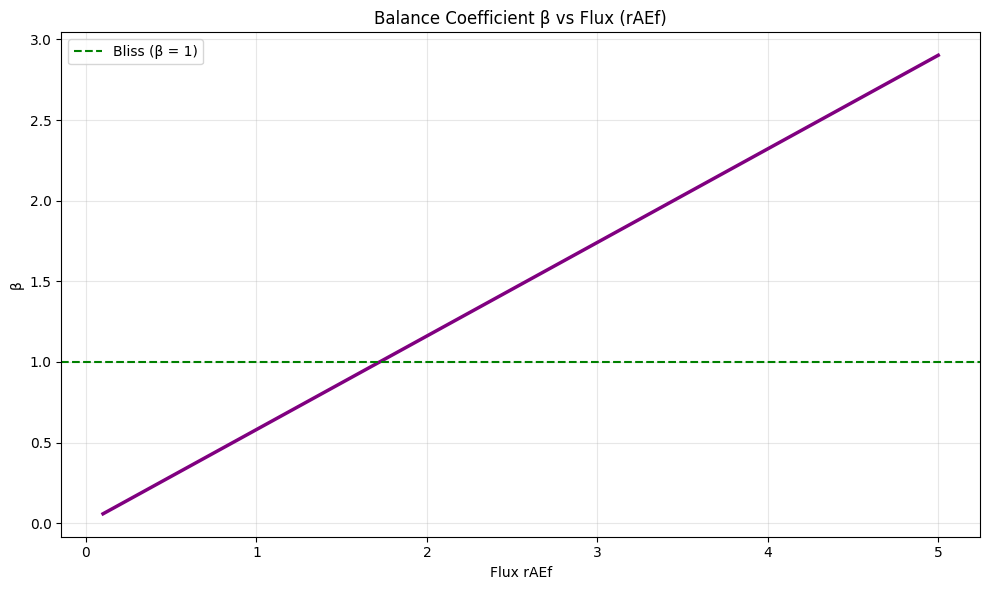

Saved to Drive: 2_balance_heatmap.png


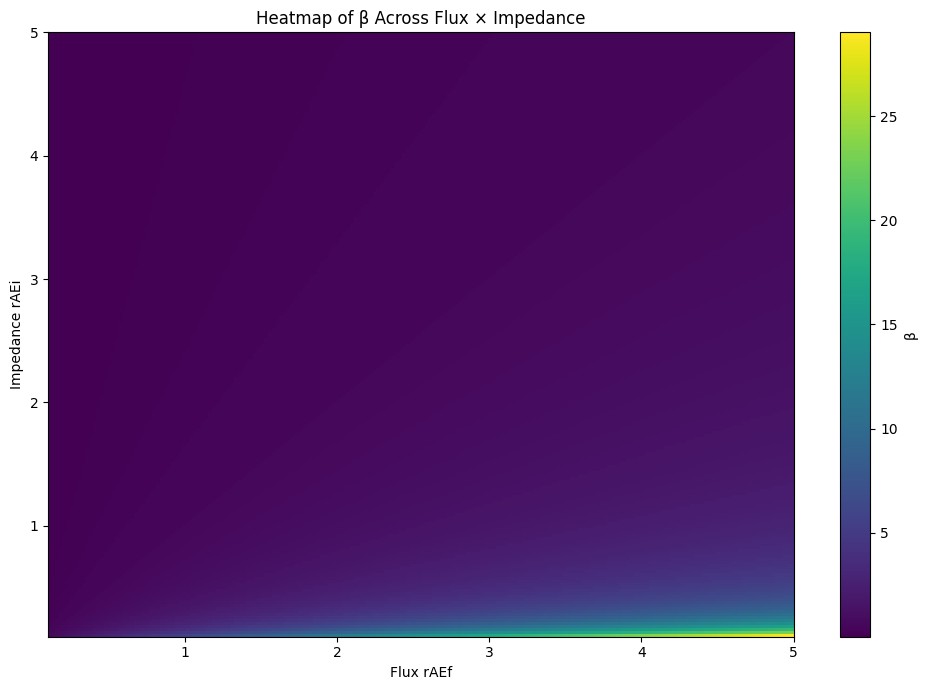

Saved to Drive: 3_balance_surface.png


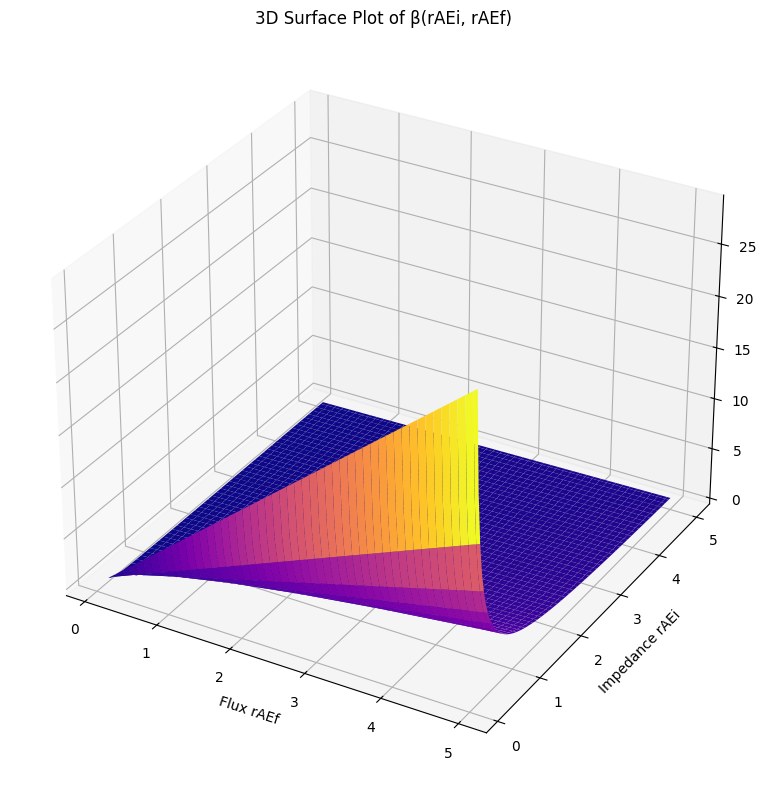

Done.


In [18]:
# sim_balance_coefficient
#!/usr/bin/env python3
# sim_balance_coefficient.py
# Auto-generated for VIM Thesis Simulation Suite

"""
Balance Coefficient Simulation
This module computes and visualizes the Balance Coefficient β across
multiple parameter regimes:

1. 2D Line Plot — β vs Flux (rAEf)
2. 2D Heatmap — β across Impedance × Flux
3. 3D Surface Plot — β(rAEi, rAEf)

β = (rAEf * rAEc) / (rAEi * rAEt)

All simulations are computational-only and safe.
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# ---------------------------------------------------------
# BALANCE COEFFICIENT FUNCTION
# ---------------------------------------------------------

def beta(rAEf, rAEc, rAEi, rAEt):
    return (rAEf * rAEc) / (rAEi * rAEt)


# ---------------------------------------------------------
# SIMULATION 1: 2D LINE PLOT
# ---------------------------------------------------------

def sim_line_plot():
    rAEc = 0.92
    rAEt = 1.585
    rAEi = 1.0

    flux_values = np.linspace(0.1, 5.0, 300)
    beta_values = beta(flux_values, rAEc, rAEi, rAEt)

    plt.figure(figsize=(10, 6))
    plt.plot(flux_values, beta_values, linewidth=2.5, color="purple")
    plt.axhline(1.0, color="green", linestyle="--", label="Bliss (β = 1)")
    plt.title("Balance Coefficient β vs Flux (rAEf)")
    plt.xlabel("Flux rAEf")
    plt.ylabel("β")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    quick_save("1_balance_line") # Updated with contextual filename
    plt.show()


# ---------------------------------------------------------
# SIMULATION 2: 2D HEATMAP
# ---------------------------------------------------------

def sim_heatmap():
    rAEc = 0.92
    rAEt = 1.585

    flux_range = np.linspace(0.1, 5.0, 200)
    imp_range = np.linspace(0.1, 5.0, 200)

    F, I = np.meshgrid(flux_range, imp_range)
    B = beta(F, rAEc, I, rAEt)

    plt.figure(figsize=(10, 7))
    plt.imshow(B, extent=[0.1, 5.0, 0.1, 5.0], origin="lower", aspect="auto", cmap="viridis")
    plt.colorbar(label="β")
    plt.title("Heatmap of β Across Flux × Impedance")
    plt.xlabel("Flux rAEf")
    plt.ylabel("Impedance rAEi")
    plt.tight_layout()
    quick_save("2_balance_heatmap") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIMULATION 3: 3D SURFACE PLOT
# ---------------------------------------------------------

def sim_surface_plot():
    rAEc = 0.92
    rAEt = 1.585

    flux_range = np.linspace(0.1, 5.0, 100)
    imp_range = np.linspace(0.1, 5.0, 100)

    F, I = np.meshgrid(flux_range, imp_range)
    B = beta(F, rAEc, I, rAEt)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(F, I, B, cmap="plasma", edgecolor="none")
    ax.set_title("3D Surface Plot of β(rAEi, rAEf)")
    ax.set_xlabel("Flux rAEf")
    ax.set_ylabel("Impedance rAEi")
    ax.set_zlabel("β")

    plt.tight_layout()
    quick_save("3_balance_surface") # Added save function
    plt.show()


# ---------------------------------------------------------
# MASTER RUNNER
# ---------------------------------------------------------

def run_simulation():
    print("Running β simulations...")
    sim_line_plot()
    sim_heatmap()
    sim_surface_plot()
    print("Done.")


if __name__ == "__main__":
    run_simulation()


Running Impedance Matching simulations...
Saved to Drive: 4_impedance_time_domain.png


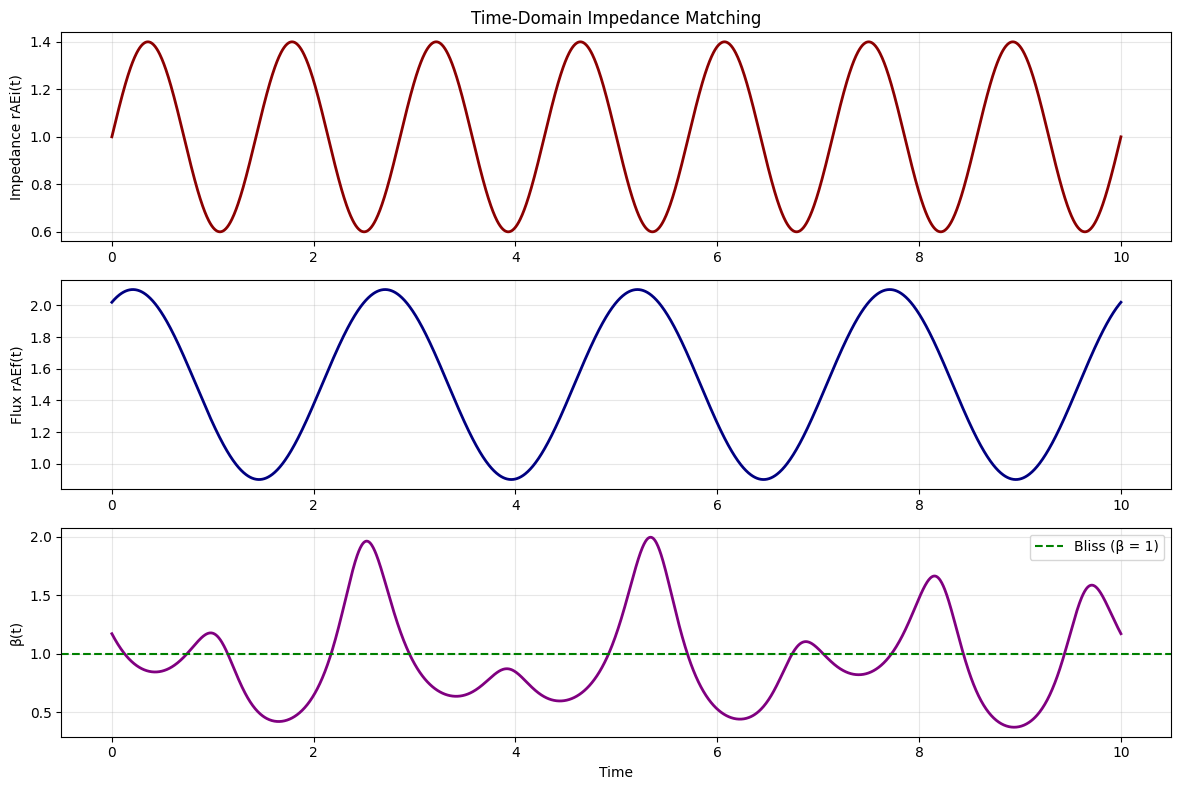

Saved to Drive: 5_impedance_frequency_domain.png


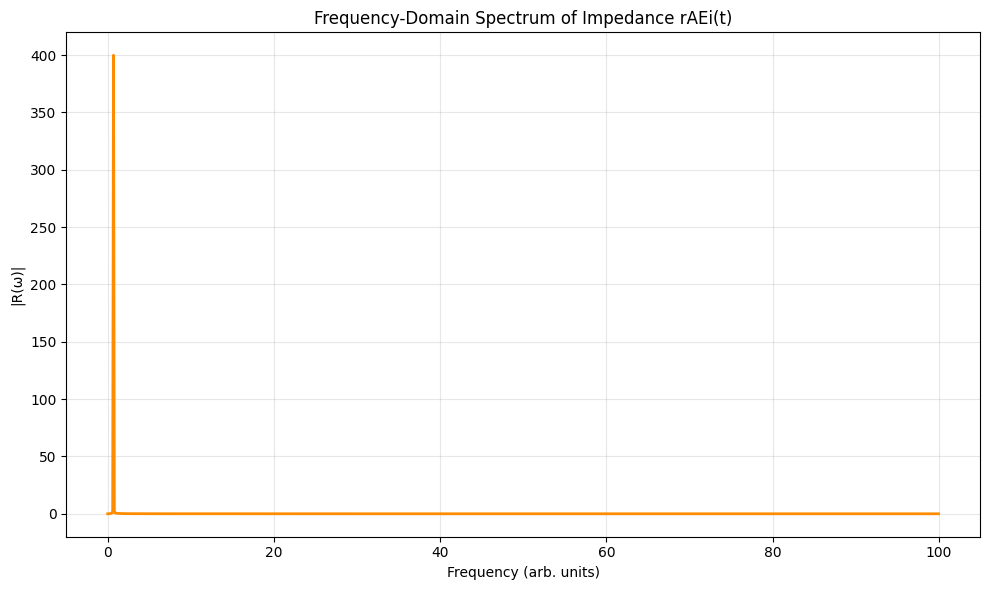

Saved to Drive: 6_impedance_phase_space.png


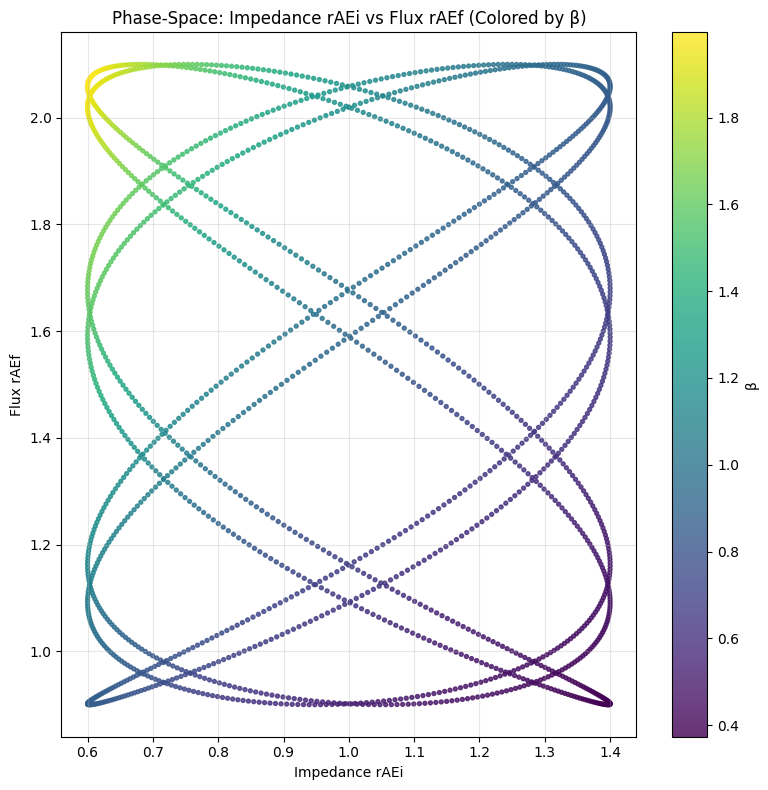

Done.


In [19]:
#!/usr/bin/env python3
# sim_impedance_matching.py
# Auto-generated for VIM Thesis Simulation Suite

"""
Impedance Matching Simulation

This module explores Vacuum Impedance Matching via:

1. Time-domain impedance modulation rAEi(t)
2. Frequency-domain magnitude spectrum |R(ω)|
3. Phase-space map: Impedance rAEi vs Flux rAEf colored by β

Core relation:
    β = (rAEf * rAEc) / (rAEi * rAEt)

All simulations are computational-only and safe.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PARAMETERS
# ---------------------------------------------------------

# Coherence and topology (fixed for this sim)
rAEc = 0.92
rAEt = 1.585

# Time axis
T = 10.0
N = 2000
t = np.linspace(0.0, T, N)


# ---------------------------------------------------------
# CORE FUNCTIONS
# ---------------------------------------------------------

def beta(rAEf, rAEc, rAEi, rAEt):
    return (rAEf * rAEc) / (rAEi * rAEt)


def impedance_profile(t, base=1.0, depth=0.4, freq=0.7):
    """
    Time-varying impedance profile rAEi(t).
    A smooth sinusoidal modulation around a base value.
    """
    return base + depth * np.sin(2 * np.pi * freq * t)


def flux_profile(t, base=1.5, depth=0.6, freq=0.4, phase=np.pi / 3):
    """
    Time-varying flux profile rAEf(t).
    Phase-shifted relative to impedance to create rich dynamics.
    """
    return base + depth * np.sin(2 * np.pi * freq * t + phase)


# ---------------------------------------------------------
# SIM 1: TIME-DOMAIN IMPEDANCE MATCHING
# ---------------------------------------------------------

def sim_time_domain():
    rAEi_t = impedance_profile(t)
    rAEf_t = flux_profile(t)
    beta_t = beta(rAEf_t, rAEc, rAEi_t, rAEt)

    plt.figure(figsize=(12, 8))

    # Impedance
    plt.subplot(3, 1, 1)
    plt.plot(t, rAEi_t, color="darkred", linewidth=2)
    plt.title("Time-Domain Impedance Matching")
    plt.ylabel("Impedance rAEi(t)")
    plt.grid(alpha=0.3)

    # Flux
    plt.subplot(3, 1, 2)
    plt.plot(t, rAEf_t, color="navy", linewidth=2)
    plt.ylabel("Flux rAEf(t)")
    plt.grid(alpha=0.3)

    # Beta
    plt.subplot(3, 1, 3)
    plt.plot(t, beta_t, color="purple", linewidth=2)
    plt.axhline(1.0, color="green", linestyle="--", label="Bliss (β = 1)")
    plt.ylabel("β(t)")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    quick_save("4_impedance_time_domain") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 2: FREQUENCY-DOMAIN IMPEDANCE SPECTRUM
# ---------------------------------------------------------

def sim_frequency_domain():
    rAEi_t = impedance_profile(t)

    # FFT
    dt = t[1] - t[0]
    R = np.fft.rfft(rAEi_t - np.mean(rAEi_t))
    freqs = np.fft.rfftfreq(len(t), dt)
    mag = np.abs(R)

    plt.figure(figsize=(10, 6))
    plt.plot(freqs, mag, color="darkorange", linewidth=2)
    plt.title("Frequency-Domain Spectrum of Impedance rAEi(t)")
    plt.xlabel("Frequency (arb. units)")
    plt.ylabel("|R(ω)|")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("5_impedance_frequency_domain") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 3: PHASE-SPACE IMPEDANCE vs FLUX (COLORED BY β)
# ---------------------------------------------------------

def sim_phase_space():
    rAEi_t = impedance_profile(t)
    rAEf_t = flux_profile(t)
    beta_t = beta(rAEf_t, rAEc, rAEi_t, rAEt)

    plt.figure(figsize=(8, 8))
    sc = plt.scatter(rAEi_t, rAEf_t, c=beta_t, cmap="viridis", s=8, alpha=0.8)
    plt.colorbar(sc, label="β")
    plt.title("Phase-Space: Impedance rAEi vs Flux rAEf (Colored by β)")
    plt.xlabel("Impedance rAEi")
    plt.ylabel("Flux rAEf")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("6_impedance_phase_space") # Added save function
    plt.show()


# ---------------------------------------------------------
# MASTER RUNNER
# ---------------------------------------------------------

def run_simulation():
    print("Running Impedance Matching simulations...")
    sim_time_domain()
    sim_frequency_domain()
    sim_phase_space()
    print("Done.")


if __name__ == "__main__":
    run_simulation()


Running Flux Dynamics simulations...
Saved to Drive: 7_flux_time_domain.png


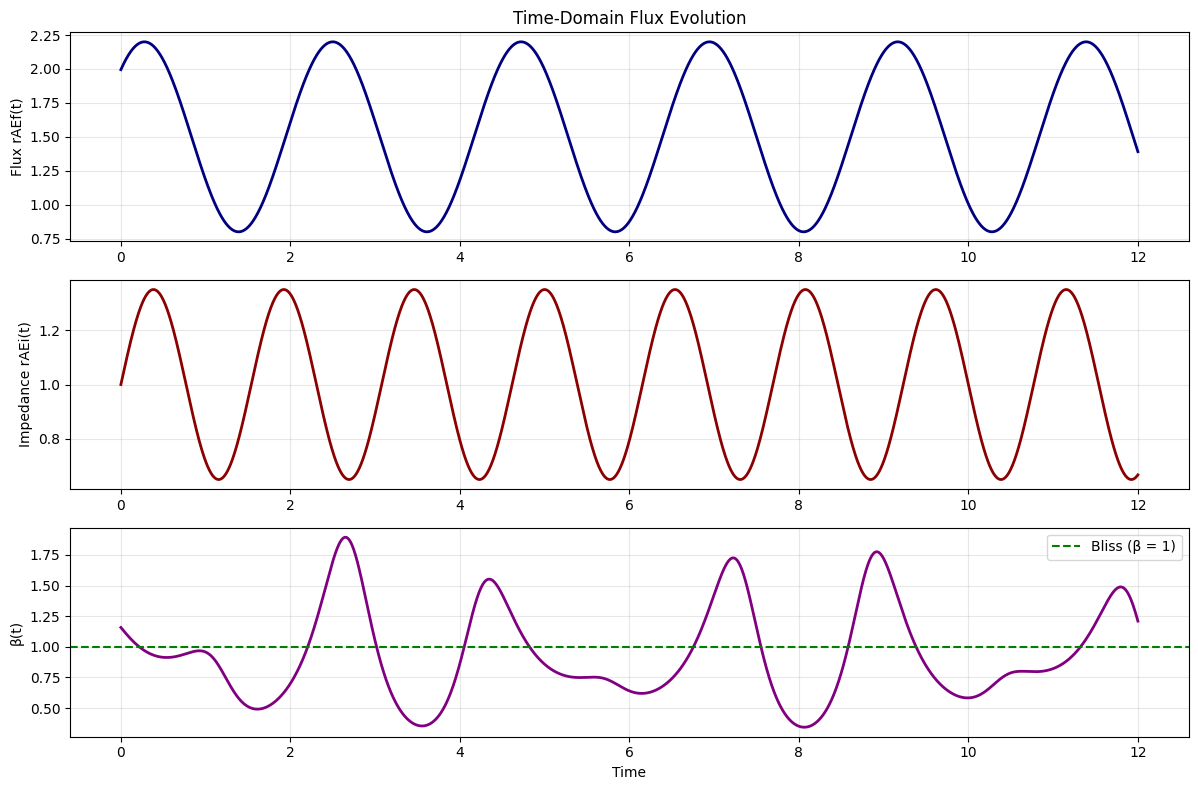

Saved to Drive: 8_flux_beta_map.png


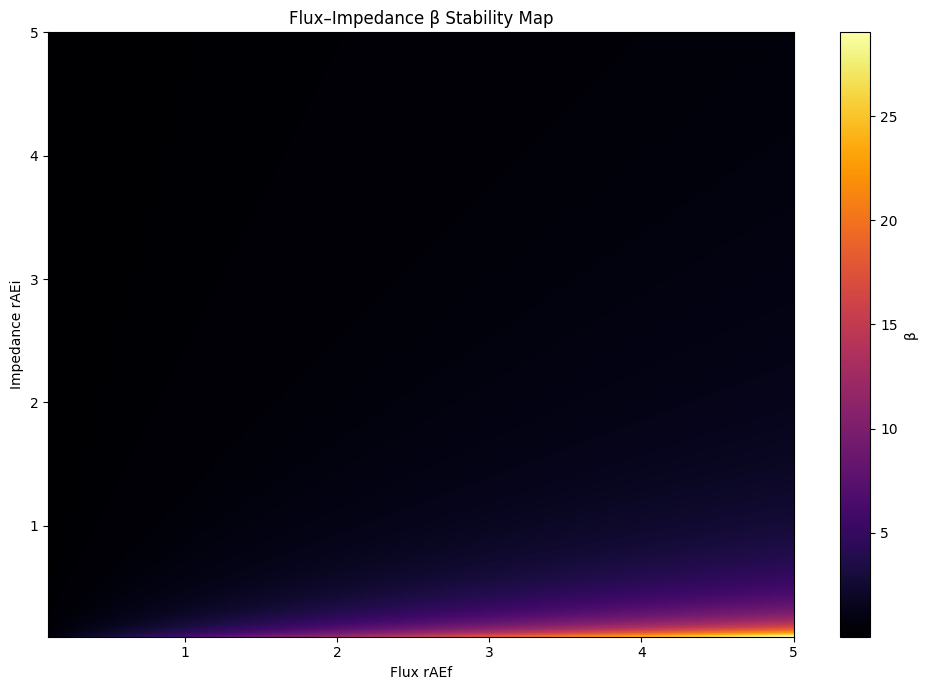

Saved to Drive: 9_flux_phase_portrait.png


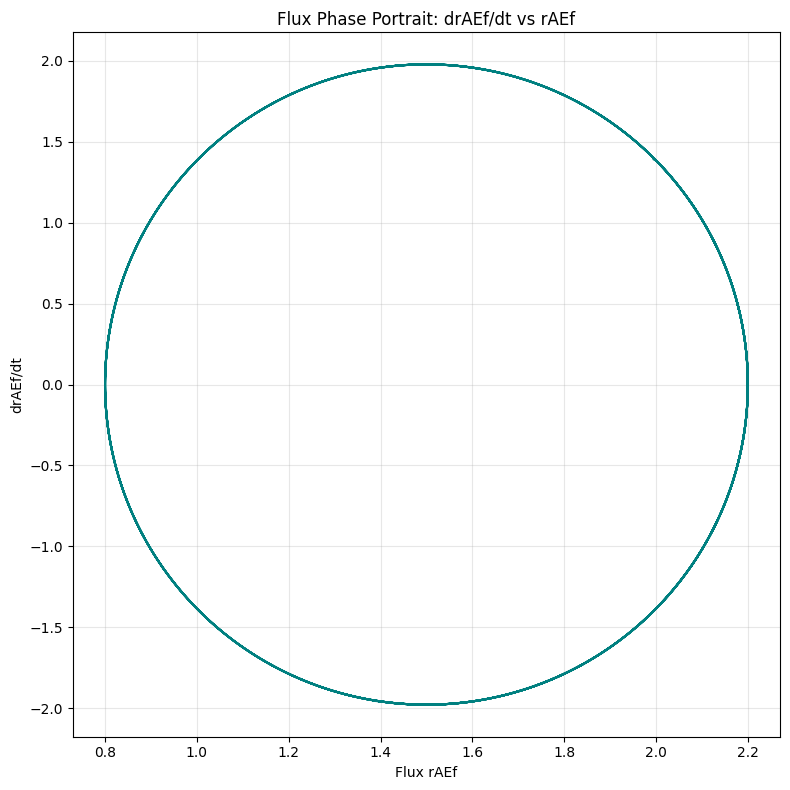

Saved to Drive: 10_flux_coherence_sweep.png


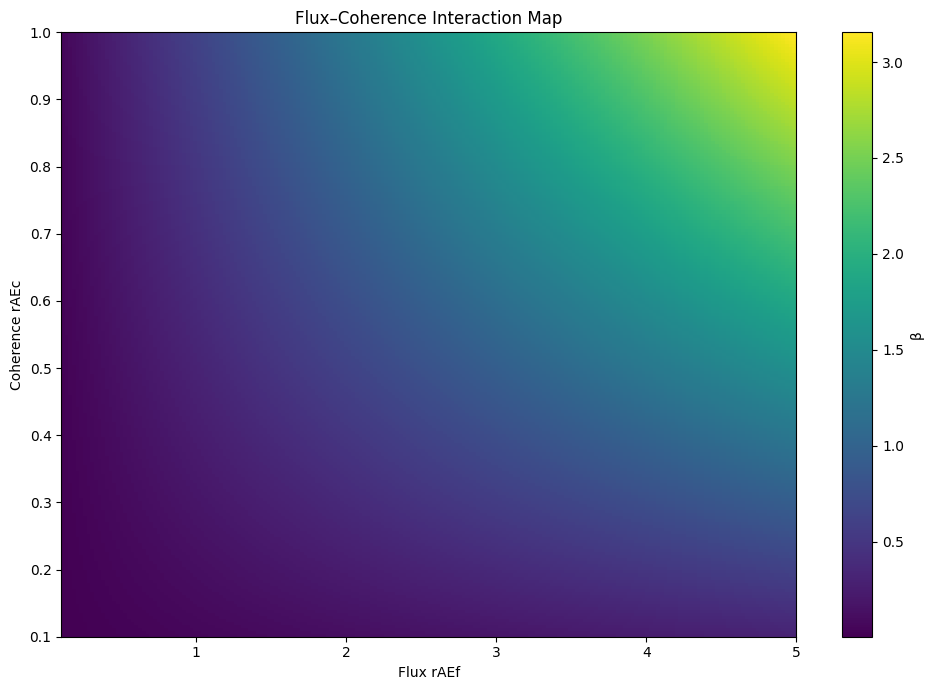

Done.


In [20]:
#!/usr/bin/env python3
# sim_flux_dynamics.py
# Auto-generated for VIM Thesis Simulation Suite

"""
Flux Dynamics Simulation

This module explores flux behavior in the VIM system via:

1. Time-domain flux evolution rAEf(t)
2. β stability map across flux × impedance
3. Flux phase portrait (drAEf/dt vs rAEf)
4. Flux–coherence interaction sweep

Core relation:
    β = (rAEf * rAEc) / (rAEi * rAEt)

All simulations are computational-only and safe.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PARAMETERS
# ---------------------------------------------------------

rAEc_default = 0.92
rAEt = 1.585

T = 12.0
N = 3000
t = np.linspace(0.0, T, N)


# ---------------------------------------------------------
# CORE FUNCTIONS
# ---------------------------------------------------------

def beta(rAEf, rAEc, rAEi, rAEt):
    return (rAEf * rAEc) / (rAEi * rAEt)


def flux_profile(t, base=1.5, depth=0.7, freq=0.45, phase=np.pi/4):
    return base + depth * np.sin(2*np.pi*freq*t + phase)


def impedance_profile(t, base=1.0, depth=0.35, freq=0.65):
    return base + depth * np.sin(2*np.pi*freq*t)


# ---------------------------------------------------------
# SIM 1: TIME-DOMAIN FLUX EVOLUTION
# ---------------------------------------------------------

def sim_flux_time_domain():
    rAEf_t = flux_profile(t)
    rAEi_t = impedance_profile(t)
    beta_t = beta(rAEf_t, rAEc_default, rAEi_t, rAEt)

    plt.figure(figsize=(12, 8))

    plt.subplot(3, 1, 1)
    plt.plot(t, rAEf_t, color="navy", linewidth=2)
    plt.title("Time-Domain Flux Evolution")
    plt.ylabel("Flux rAEf(t)")
    plt.grid(alpha=0.3)

    plt.subplot(3, 1, 2)
    plt.plot(t, rAEi_t, color="darkred", linewidth=2)
    plt.ylabel("Impedance rAEi(t)")
    plt.grid(alpha=0.3)

    plt.subplot(3, 1, 3)
    plt.plot(t, beta_t, color="purple", linewidth=2)
    plt.axhline(1.0, linestyle="--", color="green", label="Bliss (β = 1)")
    plt.ylabel("β(t)")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    quick_save("7_flux_time_domain") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 2: β STABILITY MAP (FLUX × IMPEDANCE)
# ---------------------------------------------------------

def sim_flux_beta_map():
    flux_range = np.linspace(0.1, 5.0, 300)
    imp_range = np.linspace(0.1, 5.0, 300)

    F, I = np.meshgrid(flux_range, imp_range)
    B = beta(F, rAEc_default, I, rAEt)

    plt.figure(figsize=(10, 7))
    plt.imshow(B, extent=[0.1, 5.0, 0.1, 5.0], origin="lower", aspect="auto", cmap="inferno")
    plt.colorbar(label="β")
    plt.title("Flux–Impedance β Stability Map")
    plt.xlabel("Flux rAEf")
    plt.ylabel("Impedance rAEi")
    plt.tight_layout()
    quick_save("8_flux_beta_map") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 3: FLUX PHASE PORTRAIT (drAEf/dt vs rAEf)
# ---------------------------------------------------------

def sim_flux_phase_portrait():
    rAEf_t = flux_profile(t)
    drAEf_dt = np.gradient(rAEf_t, t)

    plt.figure(figsize=(8, 8))
    plt.plot(rAEf_t, drAEf_dt, color="teal", linewidth=1.5)
    plt.title("Flux Phase Portrait: drAEf/dt vs rAEf")
    plt.xlabel("Flux rAEf")
    plt.ylabel("drAEf/dt")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("9_flux_phase_portrait") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 4: FLUX–COHERENCE INTERACTION SWEEP
# ---------------------------------------------------------

def sim_flux_coherence_sweep():
    flux_range = np.linspace(0.1, 5.0, 200)
    coherence_range = np.linspace(0.1, 1.0, 200)

    F, C = np.meshgrid(flux_range, coherence_range)
    B = beta(F, C, 1.0, rAEt)

    plt.figure(figsize=(10, 7))
    plt.imshow(B, extent=[0.1, 5.0, 0.1, 1.0], origin="lower", aspect="auto", cmap="viridis")
    plt.colorbar(label="β")
    plt.title("Flux–Coherence Interaction Map")
    plt.xlabel("Flux rAEf")
    plt.ylabel("Coherence rAEc")
    plt.tight_layout()
    quick_save("10_flux_coherence_sweep") # Added save function
    plt.show()


# ---------------------------------------------------------
# MASTER RUNNER
# ---------------------------------------------------------

def run_simulation():
    print("Running Flux Dynamics simulations...")
    sim_flux_time_domain()
    sim_flux_beta_map()
    sim_flux_phase_portrait()
    sim_flux_coherence_sweep()
    print("Done.")


if __name__ == "__main__":
    run_simulation()


Running Coherence Evolution simulations...
Saved to Drive: 11_coherence_time_domain.png


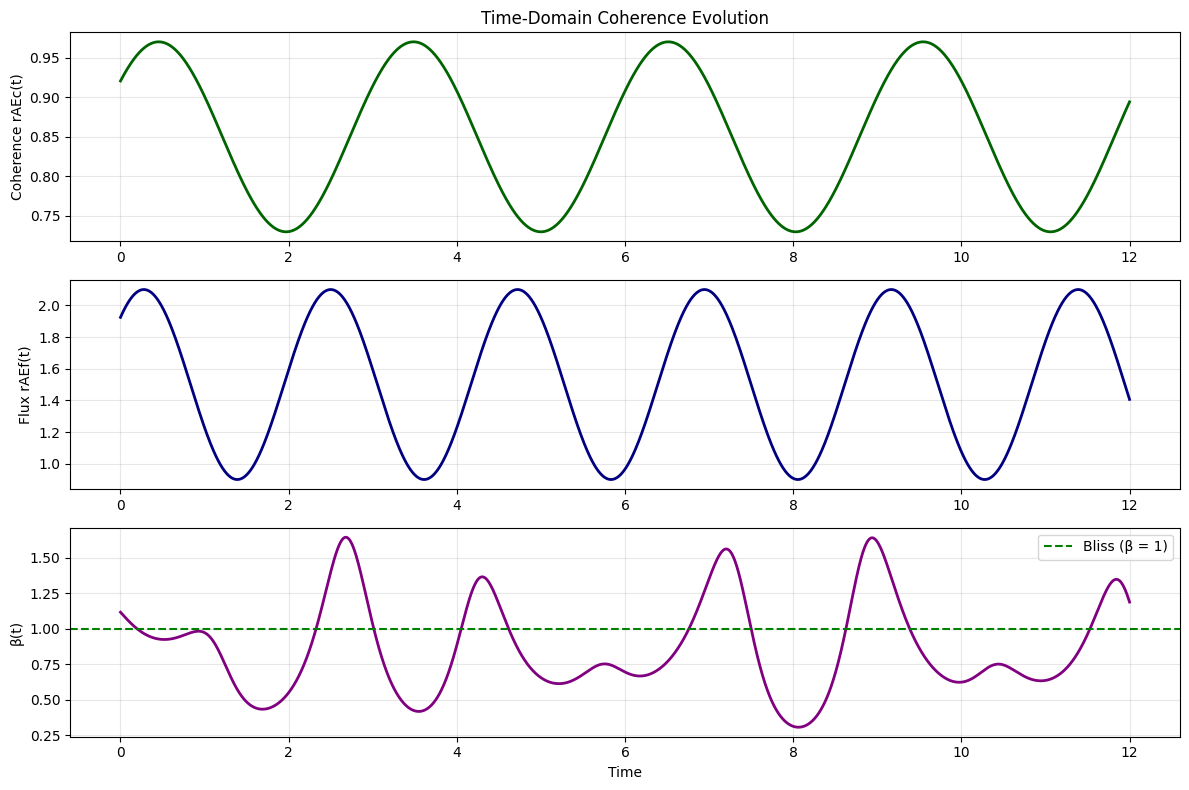

Saved to Drive: 12_coherence_beta_map.png


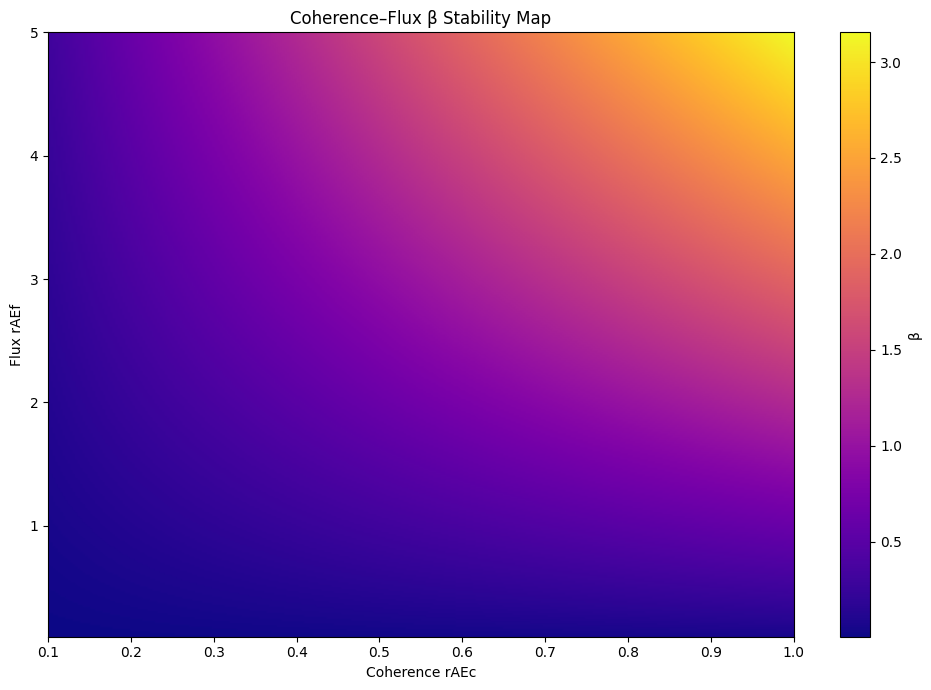

Saved to Drive: 13_coherence_phase_portrait.png


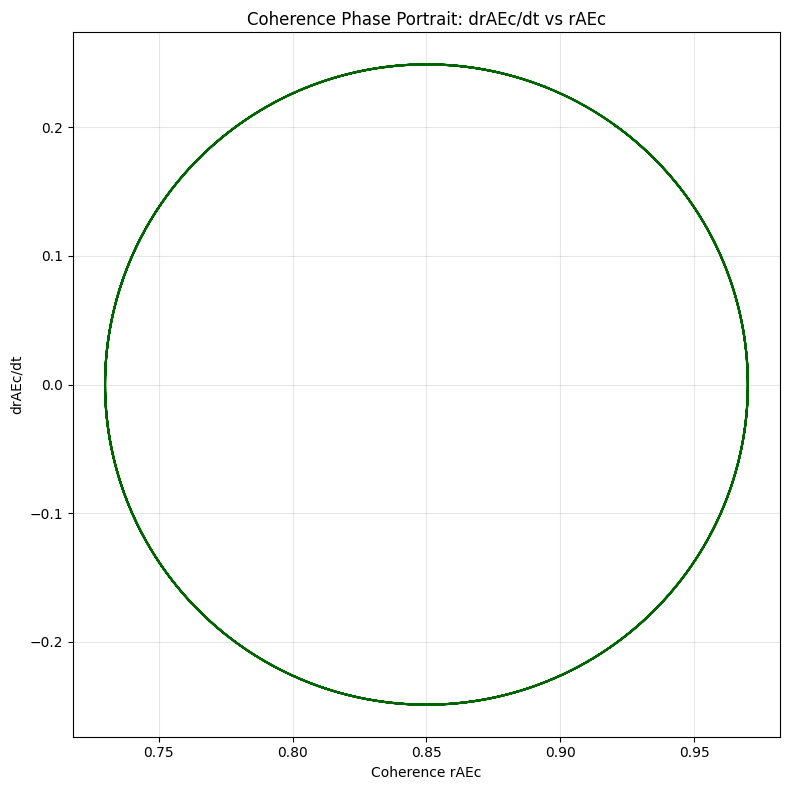

Saved to Drive: 14_coherence_impedance_sweep.png


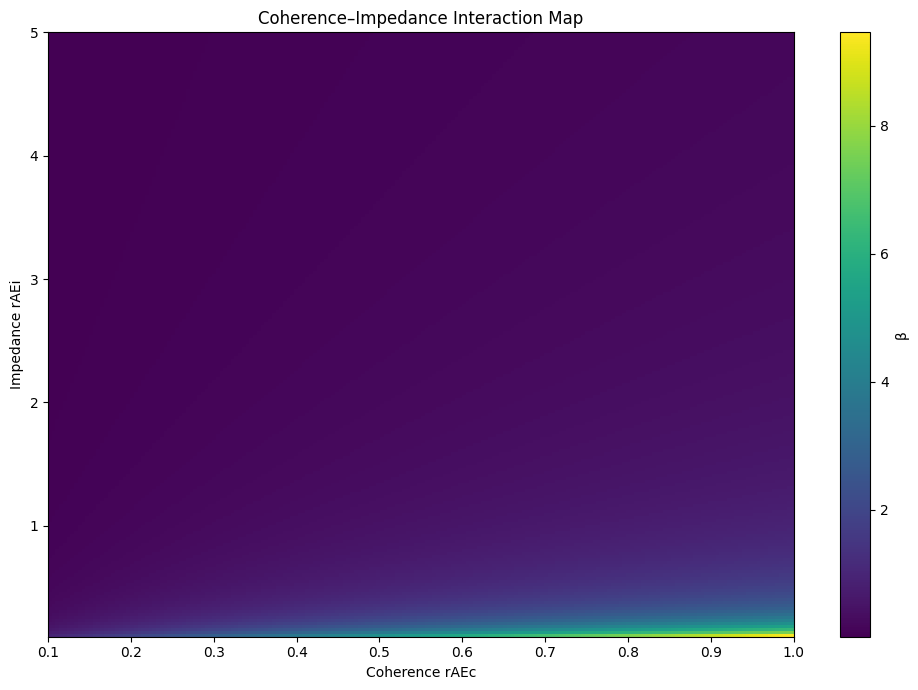

Done.


In [21]:
#!/usr/bin/env python3
# sim_coherence_evolution.py
# Auto-generated for VIM Thesis Simulation Suite

"""
Coherence Evolution Simulation

This module explores coherence behavior in the VIM system via:

1. Time-domain coherence evolution rAEc(t)
2. β stability map across coherence × flux
3. Coherence phase portrait (drAEc/dt vs rAEc)
4. Coherence–impedance interaction sweep

Core relation:
    β = (rAEf * rAEc) / (rAEi * rAEt)

All simulations are computational-only and safe.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PARAMETERS
# ---------------------------------------------------------

rAEt = 1.585

T = 12.0
N = 3000
t = np.linspace(0.0, T, N)


# ---------------------------------------------------------
# CORE FUNCTIONS
# ---------------------------------------------------------

def beta(rAEf, rAEc, rAEi, rAEt):
    return (rAEf * rAEc) / (rAEi * rAEt)


def coherence_profile(t, base=0.85, depth=0.12, freq=0.33, phase=np.pi/5):
    """
    Time-varying coherence rAEc(t).
    Smooth oscillation around a base coherence level.
    """
    return base + depth * np.sin(2*np.pi*freq*t + phase)


def flux_profile(t, base=1.5, depth=0.6, freq=0.45, phase=np.pi/4):
    return base + depth * np.sin(2*np.pi*freq*t + phase)


def impedance_profile(t, base=1.0, depth=0.35, freq=0.65):
    return base + depth * np.sin(2*np.pi*freq*t)


# ---------------------------------------------------------
# SIM 1: TIME-DOMAIN COHERENCE EVOLUTION
# ---------------------------------------------------------

def sim_coherence_time_domain():
    rAEc_t = coherence_profile(t)
    rAEf_t = flux_profile(t)
    rAEi_t = impedance_profile(t)
    beta_t = beta(rAEf_t, rAEc_t, rAEi_t, rAEt)

    plt.figure(figsize=(12, 8))

    plt.subplot(3, 1, 1)
    plt.plot(t, rAEc_t, color="darkgreen", linewidth=2)
    plt.title("Time-Domain Coherence Evolution")
    plt.ylabel("Coherence rAEc(t)")
    plt.grid(alpha=0.3)

    plt.subplot(3, 1, 2)
    plt.plot(t, rAEf_t, color="navy", linewidth=2)
    plt.ylabel("Flux rAEf(t)")
    plt.grid(alpha=0.3)

    plt.subplot(3, 1, 3)
    plt.plot(t, beta_t, color="purple", linewidth=2)
    plt.axhline(1.0, linestyle="--", color="green", label="Bliss (β = 1)")
    plt.ylabel("β(t)")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    quick_save("11_coherence_time_domain") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 2: β STABILITY MAP (COHERENCE × FLUX)
# ---------------------------------------------------------

def sim_coherence_beta_map():
    coherence_range = np.linspace(0.1, 1.0, 300)
    flux_range = np.linspace(0.1, 5.0, 300)

    C, F = np.meshgrid(coherence_range, flux_range)
    B = beta(F, C, 1.0, rAEt)

    plt.figure(figsize=(10, 7))
    plt.imshow(B, extent=[0.1, 1.0, 0.1, 5.0], origin="lower", aspect="auto", cmap="plasma")
    plt.colorbar(label="β")
    plt.title("Coherence–Flux β Stability Map")
    plt.xlabel("Coherence rAEc")
    plt.ylabel("Flux rAEf")
    plt.tight_layout()
    quick_save("12_coherence_beta_map") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 3: COHERENCE PHASE PORTRAIT (drAEc/dt vs rAEc)
# ---------------------------------------------------------

def sim_coherence_phase_portrait():
    rAEc_t = coherence_profile(t)
    drAEc_dt = np.gradient(rAEc_t, t)

    plt.figure(figsize=(8, 8))
    plt.plot(rAEc_t, drAEc_dt, color="darkgreen", linewidth=1.5)
    plt.title("Coherence Phase Portrait: drAEc/dt vs rAEc")
    plt.xlabel("Coherence rAEc")
    plt.ylabel("drAEc/dt")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("13_coherence_phase_portrait") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 4: COHERENCE–IMPEDANCE INTERACTION SWEEP
# ---------------------------------------------------------

def sim_coherence_impedance_sweep():
    coherence_range = np.linspace(0.1, 1.0, 200)
    impedance_range = np.linspace(0.1, 5.0, 200)

    C, I = np.meshgrid(coherence_range, impedance_range)
    B = beta(1.5, C, I, rAEt)

    plt.figure(figsize=(10, 7))
    plt.imshow(B, extent=[0.1, 1.0, 0.1, 5.0], origin="lower", aspect="auto", cmap="viridis")
    plt.colorbar(label="β")
    plt.title("Coherence–Impedance Interaction Map")
    plt.xlabel("Coherence rAEc")
    plt.ylabel("Impedance rAEi")
    plt.tight_layout()
    quick_save("14_coherence_impedance_sweep") # Added save function
    plt.show()


# ---------------------------------------------------------
# MASTER RUNNER
# ---------------------------------------------------------

def run_simulation():
    print("Running Coherence Evolution simulations...")
    sim_coherence_time_domain()
    sim_coherence_beta_map()
    sim_coherence_phase_portrait()
    sim_coherence_impedance_sweep()
    print("Done.")


if __name__ == "__main__":
    run_simulation()


Running Topology & Recursion simulations...
Saved to Drive: 15_topology_time_domain.png


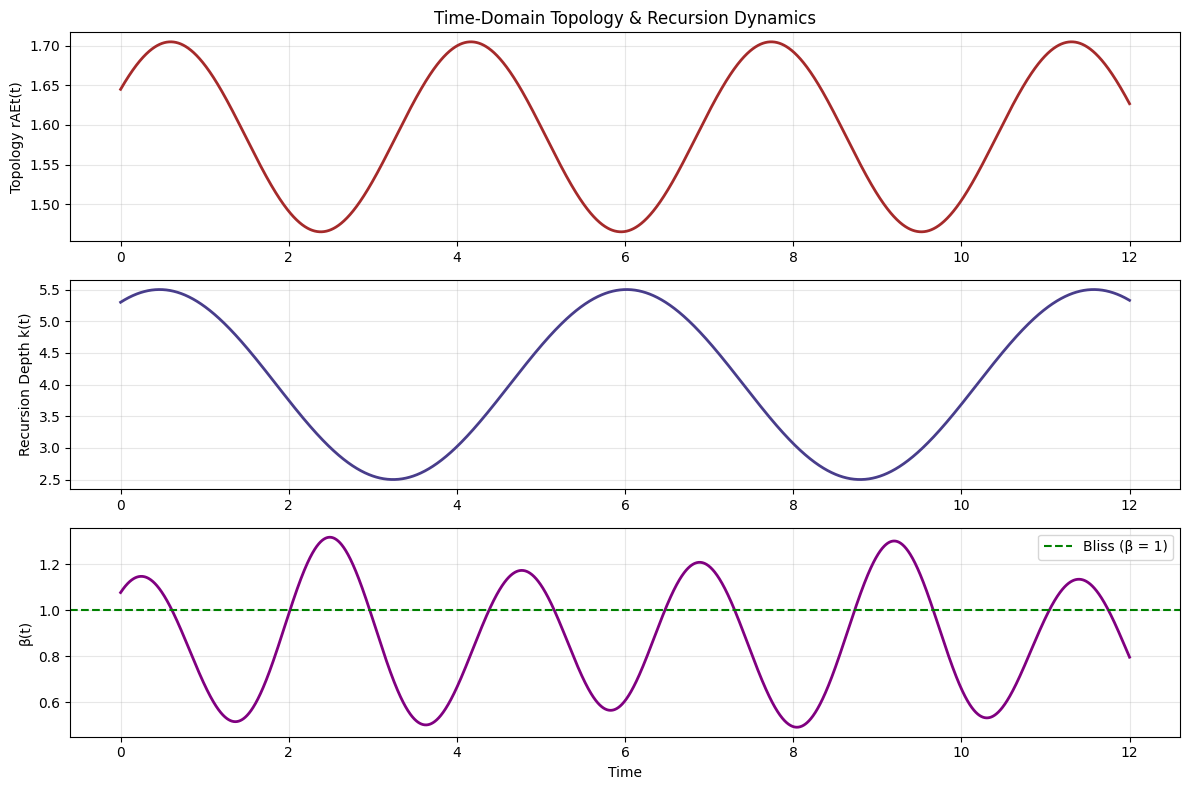

Saved to Drive: 16_topology_beta_map.png


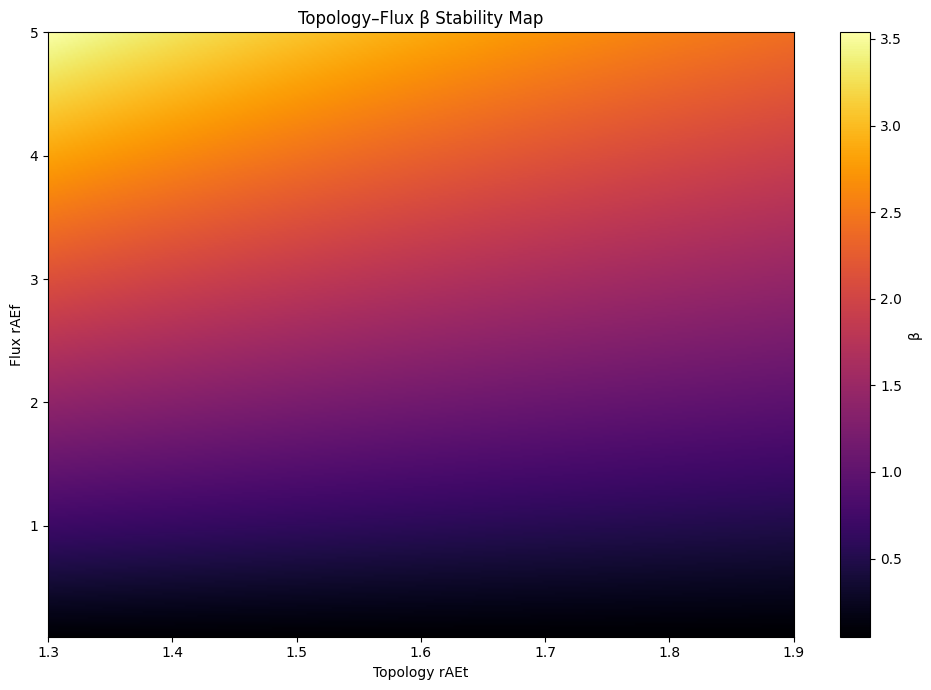

Saved to Drive: 17_topology_phase_portrait.png


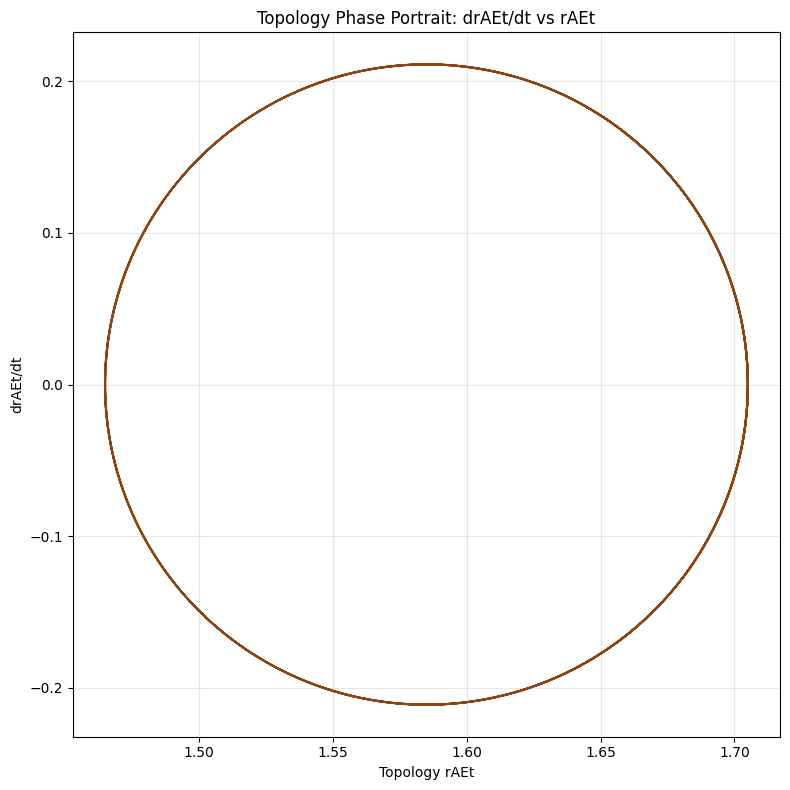

Saved to Drive: 18_recursion_topology_sweep.png


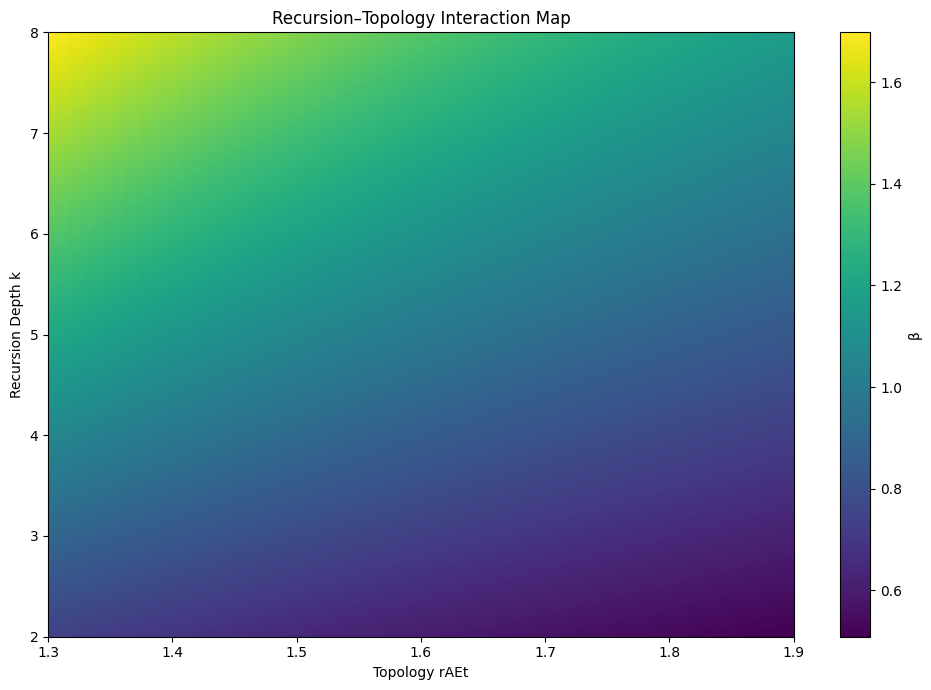

Done.


In [22]:
#!/usr/bin/env python3
# sim_topology_recursion.py
# Auto-generated for VIM Thesis Simulation Suite

"""
Topology & Recursion Simulation

This module explores topological dynamics and recursion depth in the VIM system via:

1. Time-domain topology evolution rAEt(t) and recursion depth k(t)
2. β stability map across topology × flux
3. Topology phase portrait (drAEt/dt vs rAEt)
4. Recursion–topology interaction sweep

Core relation:
    β = (rAEf * rAEc) / (rAEi * rAEt)

All simulations are computational-only and safe.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PARAMETERS
# ---------------------------------------------------------

rAEc_default = 0.92
rAEi_default = 1.0

T = 12.0
N = 3000
t = np.linspace(0.0, T, N)


# ---------------------------------------------------------
# CORE FUNCTIONS
# ---------------------------------------------------------

def beta(rAEf, rAEc, rAEi, rAEt):
    return (rAEf * rAEc) / (rAEi * rAEt)


def topology_profile(t, base=1.585, depth=0.12, freq=0.28, phase=np.pi/6):
    """
    Time-varying effective topology rAEt(t).
    Interpreted as a modulation of the active fractal dimension.
    """
    return base + depth * np.sin(2*np.pi*freq*t + phase)


def recursion_depth_profile(t, base=4.0, depth=1.5, freq=0.18, phase=np.pi/3):
    """
    Time-varying recursion depth k(t).
    Higher k corresponds to deeper fractal recursion.
    """
    return base + depth * np.sin(2*np.pi*freq*t + phase)


def flux_profile(t, base=1.5, depth=0.6, freq=0.45, phase=np.pi/4):
    return base + depth * np.sin(2*np.pi*freq*t + phase)


# ---------------------------------------------------------
# SIM 1: TIME-DOMAIN TOPOLOGY & RECURSION
# ---------------------------------------------------------

def sim_topology_time_domain():
    rAEt_t = topology_profile(t)
    k_t = recursion_depth_profile(t)
    rAEf_t = flux_profile(t)
    beta_t = beta(rAEf_t, rAEc_default, rAEi_default, rAEt_t)

    plt.figure(figsize=(12, 8))

    plt.subplot(3, 1, 1)
    plt.plot(t, rAEt_t, color="brown", linewidth=2)
    plt.title("Time-Domain Topology & Recursion Dynamics")
    plt.ylabel("Topology rAEt(t)")
    plt.grid(alpha=0.3)

    plt.subplot(3, 1, 2)
    plt.plot(t, k_t, color="darkslateblue", linewidth=2)
    plt.ylabel("Recursion Depth k(t)")
    plt.grid(alpha=0.3)

    plt.subplot(3, 1, 3)
    plt.plot(t, beta_t, color="purple", linewidth=2)
    plt.axhline(1.0, linestyle="--", color="green", label="Bliss (β = 1)")
    plt.ylabel("β(t)")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    quick_save("15_topology_time_domain") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 2: β STABILITY MAP (TOPOLOGY × FLUX)
# ---------------------------------------------------------

def sim_topology_beta_map():
    topology_range = np.linspace(1.3, 1.9, 300)
    flux_range = np.linspace(0.1, 5.0, 300)

    T_grid, F_grid = np.meshgrid(topology_range, flux_range)
    B = beta(F_grid, rAEc_default, rAEi_default, T_grid)

    plt.figure(figsize=(10, 7))
    plt.imshow(B, extent=[1.3, 1.9, 0.1, 5.0], origin="lower", aspect="auto", cmap="inferno")
    plt.colorbar(label="β")
    plt.title("Topology–Flux β Stability Map")
    plt.xlabel("Topology rAEt")
    plt.ylabel("Flux rAEf")
    plt.tight_layout()
    quick_save("16_topology_beta_map") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 3: TOPOLOGY PHASE PORTRAIT (drAEt/dt vs rAEt)
# ---------------------------------------------------------

def sim_topology_phase_portrait():
    rAEt_t = topology_profile(t)
    drAEt_dt = np.gradient(rAEt_t, t)

    plt.figure(figsize=(8, 8))
    plt.plot(rAEt_t, drAEt_dt, color="saddlebrown", linewidth=1.5)
    plt.title("Topology Phase Portrait: drAEt/dt vs rAEt")
    plt.xlabel("Topology rAEt")
    plt.ylabel("drAEt/dt")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("17_topology_phase_portrait") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 4: RECURSION–TOPOLOGY INTERACTION SWEEP
# ---------------------------------------------------------

def sim_recursion_topology_sweep():
    topology_range = np.linspace(1.3, 1.9, 200)
    recursion_range = np.linspace(2.0, 8.0, 200)

    T_grid, K_grid = np.meshgrid(topology_range, recursion_range)

    # Interpret deeper recursion as effectively amplifying flux
    effective_flux = 1.5 * (1.0 + 0.15 * (K_grid - 4.0))
    B = beta(effective_flux, rAEc_default, rAEi_default, T_grid)

    plt.figure(figsize=(10, 7))
    plt.imshow(B, extent=[1.3, 1.9, 2.0, 8.0], origin="lower", aspect="auto", cmap="viridis")
    plt.colorbar(label="β")
    plt.title("Recursion–Topology Interaction Map")
    plt.xlabel("Topology rAEt")
    plt.ylabel("Recursion Depth k")
    plt.tight_layout()
    quick_save("18_recursion_topology_sweep") # Added save function
    plt.show()


# ---------------------------------------------------------
# MASTER RUNNER
# ---------------------------------------------------------

def run_simulation():
    print("Running Topology & Recursion simulations...")
    sim_topology_time_domain()
    sim_topology_beta_map()
    sim_topology_phase_portrait()
    sim_recursion_topology_sweep()
    print("Done.")


if __name__ == "__main__":
    run_simulation()


Running Harmonic Stabilizer simulations...
Saved to Drive: 19_stabilizer_closed_loop.png


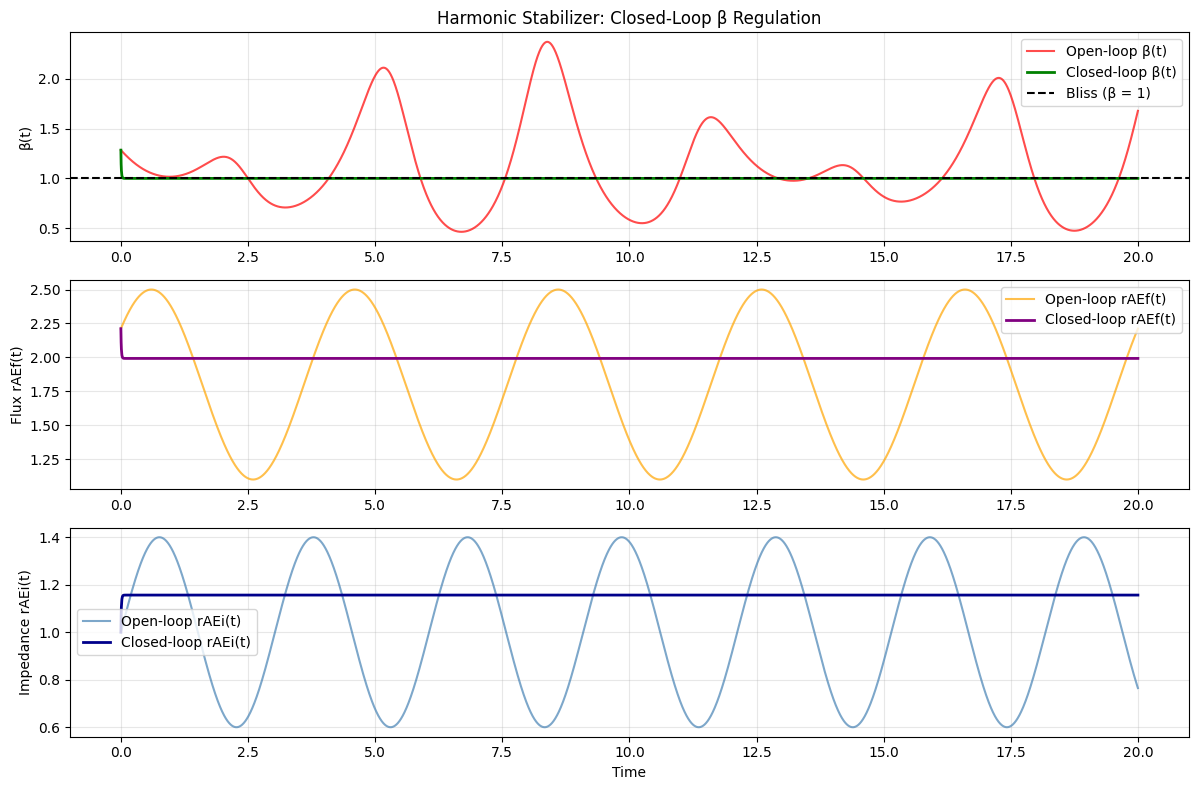

Saved to Drive: 20_stabilizer_control_surface.png


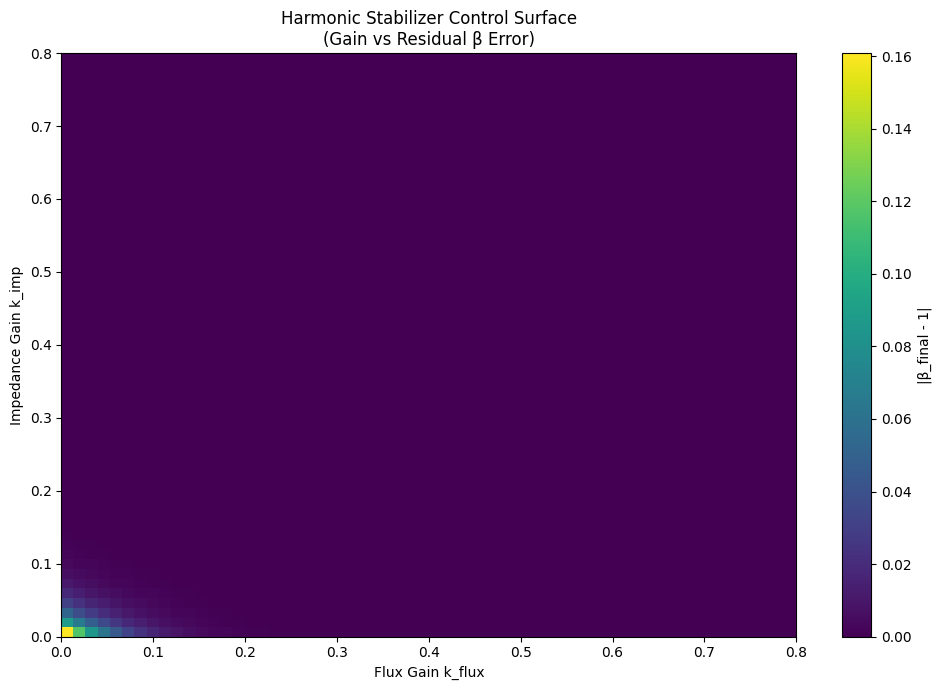

Saved to Drive: 21_stabilizer_phase_portrait.png


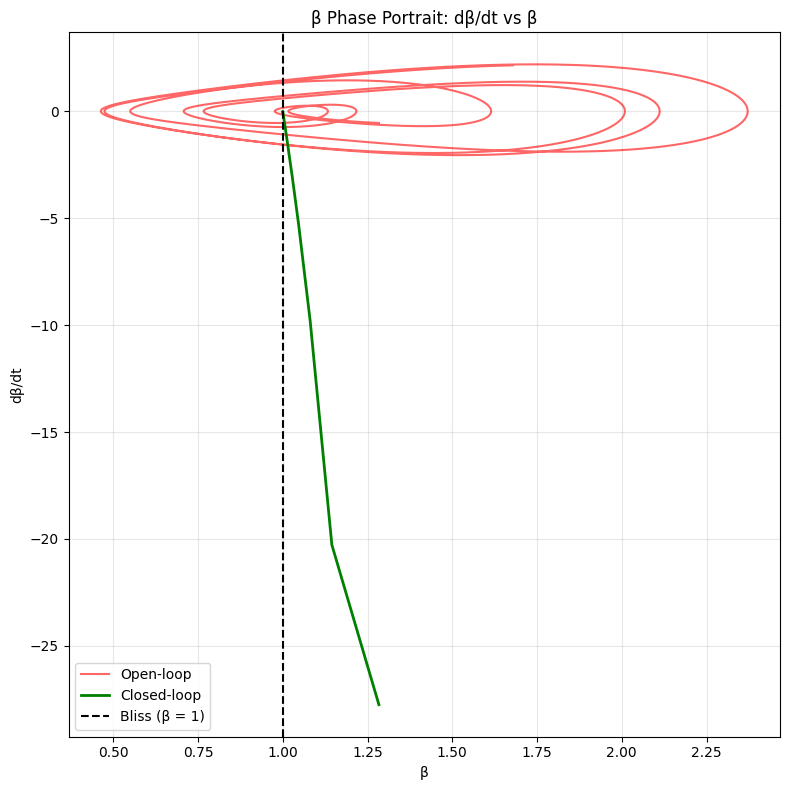

Saved to Drive: 22_stabilizer_performance_map.png


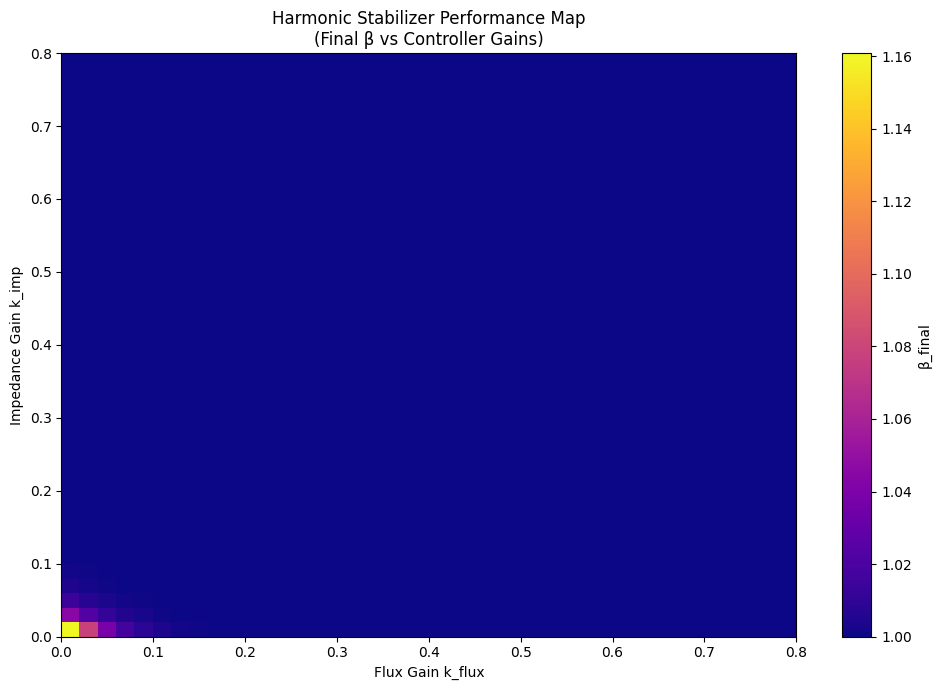

Done.


In [23]:
#!/usr/bin/env python3
# sim_harmonic_stabilizer.py
# Auto-generated for VIM Thesis Simulation Suite

"""
Harmonic Stabilizer Simulation

This module explores the behavior of the Harmonic Stabilizer in the VIM system via:

1. Closed-loop β regulation over time (with and without stabilizer)
2. Control surface: stabilizer gain vs β error
3. Phase portrait in (β, dβ/dt) space
4. Stabilizer performance map across controller gains

Core relation:
    β = (rAEf * rAEc) / (rAEi * rAEt)

The stabilizer acts by modulating rAEf and rAEi to drive β → 1 (Bliss).

All simulations are computational-only and safe.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PARAMETERS
# ---------------------------------------------------------

rAEc_default = 0.92
rAEt_default = 1.585

T = 20.0
N = 4000
t = np.linspace(0.0, T, N)
dt = t[1] - t[0]

B_TARGET = 1.0  # Bliss


# ---------------------------------------------------------
# CORE FUNCTIONS
# ---------------------------------------------------------

def beta(rAEf, rAEc, rAEi, rAEt):
    return (rAEf * rAEc) / (rAEi * rAEt)


def open_loop_flux(t, base=1.8, depth=0.7, freq=0.25, phase=np.pi/5):
    return base + depth * np.sin(2*np.pi*freq*t + phase)


def open_loop_impedance(t, base=1.0, depth=0.4, freq=0.33):
    return base + depth * np.sin(2*np.pi*freq*t)


def harmonic_stabilizer_step(rAEf, rAEi, beta_val, k_flux=0.4, k_imp=0.3):
    """
    Simple proportional controller:
    - If β > 1 (hunger): reduce flux, increase impedance
    - If β < 1 (leak): increase flux, reduce impedance
    """
    error = B_TARGET - beta_val
    rAEf_new = rAEf + k_flux * error
    rAEi_new = rAEi - k_imp * error
    return rAEf_new, rAEi_new


# ---------------------------------------------------------
# SIM 1: CLOSED-LOOP β REGULATION
# ---------------------------------------------------------

def sim_closed_loop_regulation():
    rAEf_ol = open_loop_flux(t)
    rAEi_ol = open_loop_impedance(t)

    beta_ol = beta(rAEf_ol, rAEc_default, rAEi_ol, rAEt_default)

    rAEf_cl = np.zeros_like(t)
    rAEi_cl = np.zeros_like(t)
    beta_cl = np.zeros_like(t)

    rAEf_cl[0] = rAEf_ol[0]
    rAEi_cl[0] = rAEi_ol[0]
    beta_cl[0] = beta(rAEf_cl[0], rAEc_default, rAEi_cl[0], rAEt_default)

    for i in range(1, len(t)):
        rAEf_tmp, rAEi_tmp = harmonic_stabilizer_step(
            rAEf_cl[i-1],
            rAEi_cl[i-1],
            beta_cl[i-1],
            k_flux=0.35,
            k_imp=0.25
        )
        rAEf_cl[i] = rAEf_tmp
        rAEi_cl[i] = rAEi_tmp
        beta_cl[i] = beta(rAEf_cl[i], rAEc_default, rAEi_cl[i], rAEt_default)

    plt.figure(figsize=(12, 8))

    plt.subplot(3, 1, 1)
    plt.plot(t, beta_ol, color="red", alpha=0.7, label="Open-loop β(t)")
    plt.plot(t, beta_cl, color="green", linewidth=2, label="Closed-loop β(t)")
    plt.axhline(1.0, linestyle="--", color="black", label="Bliss (β = 1)")
    plt.title("Harmonic Stabilizer: Closed-Loop β Regulation")
    plt.ylabel("β(t)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(3, 1, 2)
    plt.plot(t, rAEf_ol, color="orange", alpha=0.7, label="Open-loop rAEf(t)")
    plt.plot(t, rAEf_cl, color="purple", linewidth=2, label="Closed-loop rAEf(t)")
    plt.ylabel("Flux rAEf(t)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(3, 1, 3)
    plt.plot(t, rAEi_ol, color="steelblue", alpha=0.7, label="Open-loop rAEi(t)")
    plt.plot(t, rAEi_cl, color="darkblue", linewidth=2, label="Closed-loop rAEi(t)")
    plt.ylabel("Impedance rAEi(t)")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    quick_save("19_stabilizer_closed_loop") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 2: CONTROL SURFACE (GAIN vs β ERROR)
# ---------------------------------------------------------

def sim_control_surface():
    k_flux_vals = np.linspace(0.0, 0.8, 60)
    k_imp_vals = np.linspace(0.0, 0.8, 60)

    Kf, Ki = np.meshgrid(k_flux_vals, k_imp_vals)
    error_metric = np.zeros_like(Kf)

    for i in range(Kf.shape[0]):
        for j in range(Kf.shape[1]):
            rAEf = 2.0
            rAEi = 1.0
            beta_val = beta(rAEf, rAEc_default, rAEi, rAEt_default)
            for _ in range(40):
                rAEf, rAEi = harmonic_stabilizer_step(rAEf, rAEi, beta_val,
                                                      k_flux=Kf[i, j],
                                                      k_imp=Ki[i, j])
                beta_val = beta(rAEf, rAEc_default, rAEi, rAEt_default)
            error_metric[i, j] = abs(beta_val - B_TARGET)

    plt.figure(figsize=(10, 7))
    plt.imshow(error_metric, extent=[0.0, 0.8, 0.0, 0.8],
               origin="lower", aspect="auto", cmap="viridis")
    plt.colorbar(label="|β_final - 1|")
    plt.title("Harmonic Stabilizer Control Surface\n(Gain vs Residual β Error)")
    plt.xlabel("Flux Gain k_flux")
    plt.ylabel("Impedance Gain k_imp")
    plt.tight_layout()
    quick_save("20_stabilizer_control_surface") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 3: PHASE PORTRAIT IN (β, dβ/dt)
# ---------------------------------------------------------

def sim_beta_phase_portrait():
    rAEf_ol = open_loop_flux(t)
    rAEi_ol = open_loop_impedance(t)
    beta_ol = beta(rAEf_ol, rAEc_default, rAEi_ol, rAEt_default)
    dbeta_dt_ol = np.gradient(beta_ol, t)

    rAEf_cl = np.zeros_like(t)
    rAEi_cl = np.zeros_like(t)
    beta_cl = np.zeros_like(t)

    rAEf_cl[0] = rAEf_ol[0]
    rAEi_cl[0] = rAEi_ol[0]
    beta_cl[0] = beta(rAEf_cl[0], rAEc_default, rAEi_cl[0], rAEt_default)

    for i in range(1, len(t)):
        rAEf_tmp, rAEi_tmp = harmonic_stabilizer_step(
            rAEf_cl[i-1],
            rAEi_cl[i-1],
            beta_cl[i-1],
            k_flux=0.35,
            k_imp=0.25
        )
        rAEf_cl[i] = rAEf_tmp
        rAEi_cl[i] = rAEi_tmp
        beta_cl[i] = beta(rAEf_cl[i], rAEc_default, rAEi_cl[i], rAEt_default)

    dbeta_dt_cl = np.gradient(beta_cl, t)

    plt.figure(figsize=(8, 8))
    plt.plot(beta_ol, dbeta_dt_ol, color="red", alpha=0.6, label="Open-loop")
    plt.plot(beta_cl, dbeta_dt_cl, color="green", linewidth=2, label="Closed-loop")
    plt.axvline(1.0, linestyle="--", color="black", label="Bliss (β = 1)")
    plt.title("β Phase Portrait: dβ/dt vs β")
    plt.xlabel("β")
    plt.ylabel("dβ/dt")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("21_stabilizer_phase_portrait") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 4: STABILIZER PERFORMANCE MAP
# ---------------------------------------------------------

def sim_stabilizer_performance_map():
    k_flux_vals = np.linspace(0.0, 0.8, 40)
    k_imp_vals = np.linspace(0.0, 0.8, 40)

    Kf, Ki = np.meshgrid(k_flux_vals, k_imp_vals)
    convergence = np.zeros_like(Kf)

    for i in range(Kf.shape[0]):
        for j in range(Kf.shape[1]):
            rAEf = 2.0
            rAEi = 1.0
            beta_val = beta(rAEf, rAEc_default, rAEi, rAEt_default)
            for _ in range(60):
                rAEf, rAEi = harmonic_stabilizer_step(rAEf, rAEi, beta_val,
                                                      k_flux=Kf[i, j],
                                                      k_imp=Ki[i, j])
                beta_val = beta(rAEf, rAEc_default, rAEi, rAEt_default)
            convergence[i, j] = beta_val

    plt.figure(figsize=(10, 7))
    plt.imshow(convergence, extent=[0.0, 0.8, 0.0, 0.8],
               origin="lower", aspect="auto", cmap="plasma")
    plt.colorbar(label="β_final")
    plt.title("Harmonic Stabilizer Performance Map\n(Final β vs Controller Gains)")
    plt.xlabel("Flux Gain k_flux")
    plt.ylabel("Impedance Gain k_imp")
    plt.tight_layout()
    quick_save("22_stabilizer_performance_map") # Added save function
    plt.show()


# ---------------------------------------------------------
# MASTER RUNNER
# ---------------------------------------------------------

def run_simulation():
    print("Running Harmonic Stabilizer simulations...")
    sim_closed_loop_regulation()
    sim_control_surface()
    sim_beta_phase_portrait()
    sim_stabilizer_performance_map()
    print("Done.")


if __name__ == "__main__":
    run_simulation()


Running Bliss State Convergence simulations...
Saved to Drive: 23_bliss_convergence_trajectories.png


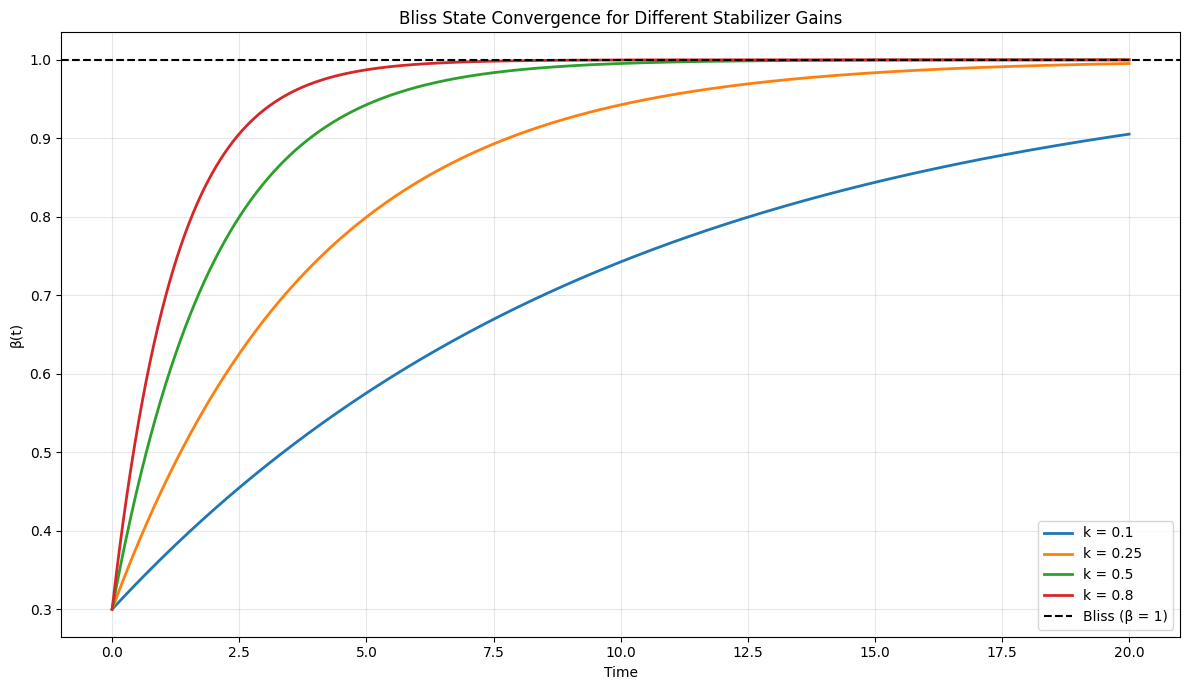

Saved to Drive: 24_bliss_basin_of_attraction.png


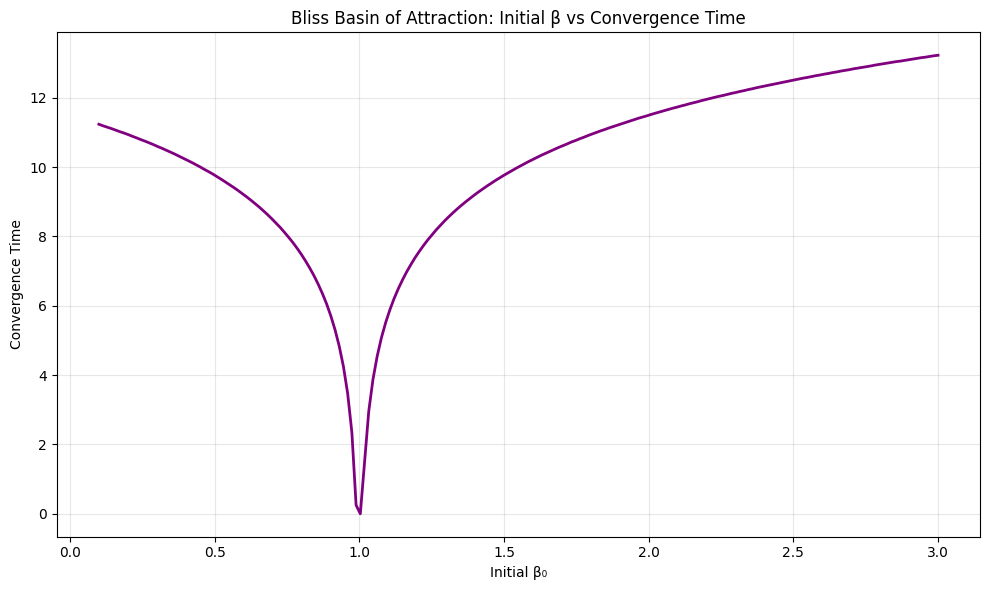

Saved to Drive: 25_bliss_phase_portrait.png


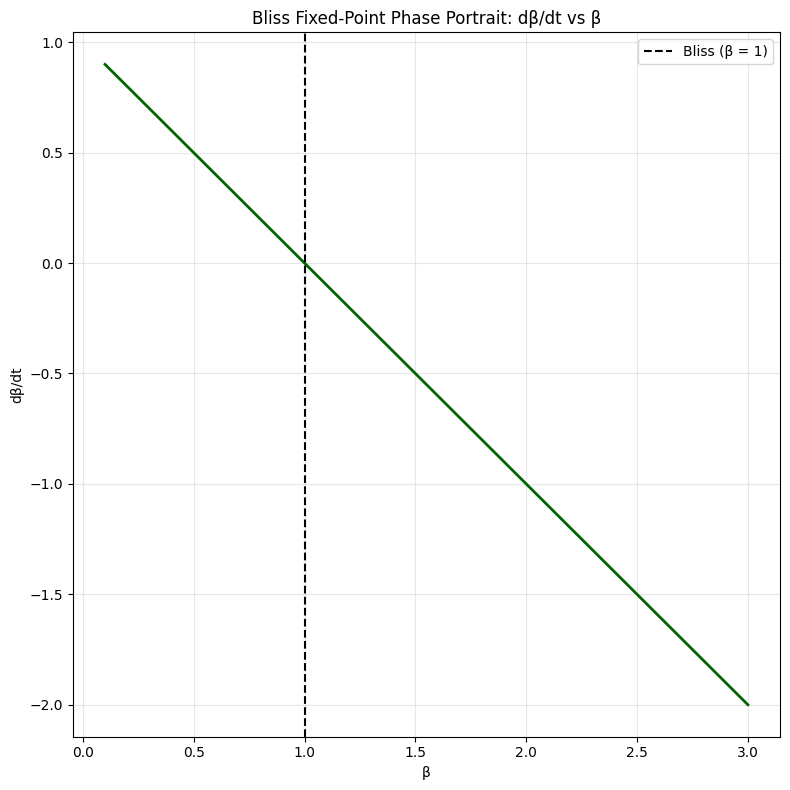

Saved to Drive: 26_bliss_stability_heatmap.png


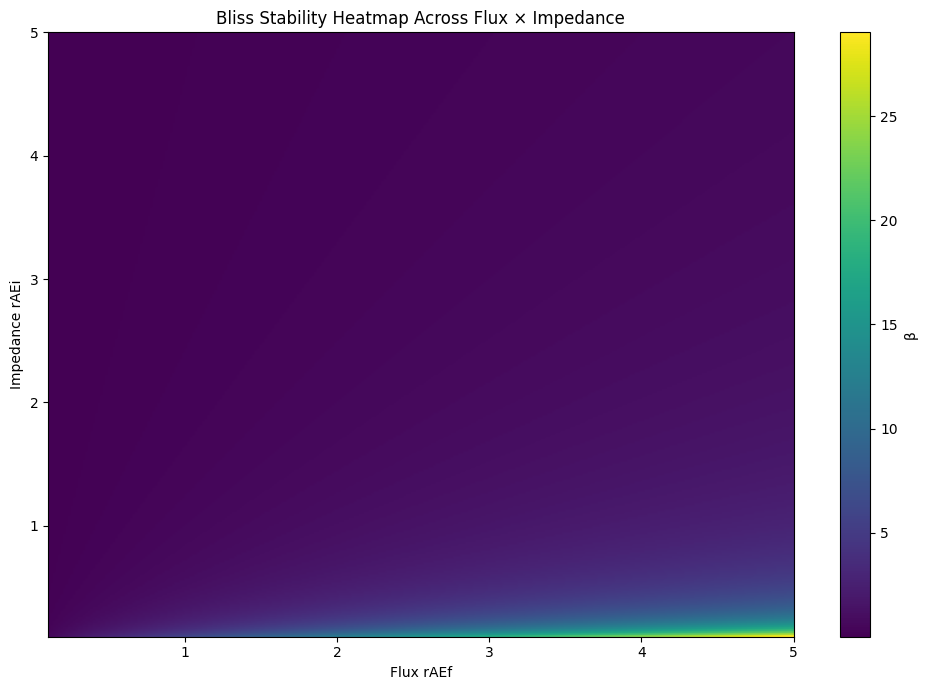

Saved to Drive: 27_bliss_convergence_waterfall.png


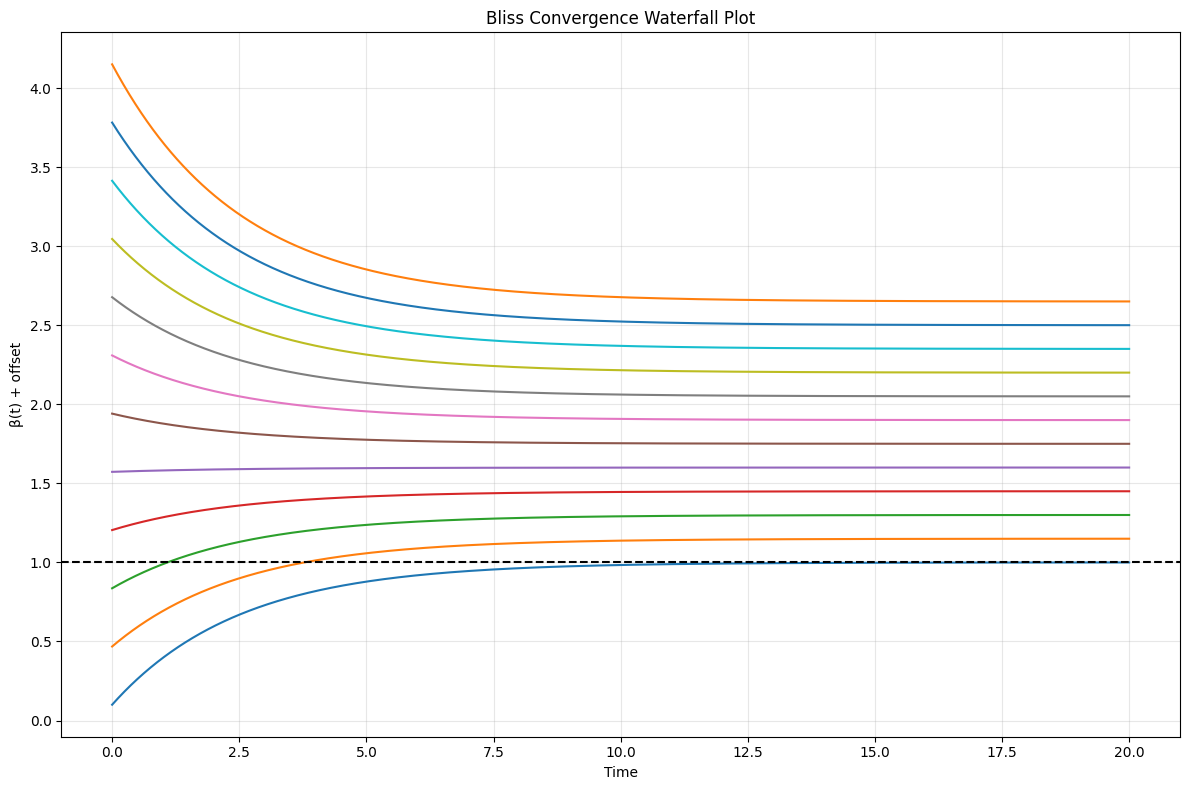

Done.


In [24]:
#!/usr/bin/env python3
# sim_bliss_state_convergence.py
# Auto-generated for VIM Thesis Simulation Suite

"""
Bliss State Convergence Simulation

This module explores how β converges to the Bliss State (β = 1) via:

1. Convergence trajectories under different stabilizer gains
2. Basin of attraction: initial β0 vs convergence time
3. Bliss fixed-point phase portrait (β, dβ/dt)
4. Bliss stability heatmap across flux × impedance
5. Convergence waterfall plot for multiple initial conditions

Core relation:
    β = (rAEf * rAEc) / (rAEi * rAEt)

The Bliss State is the fixed point β* = 1.

All simulations are computational-only and safe.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PARAMETERS
# ---------------------------------------------------------

rAEc = 0.92
rAEt = 1.585

T = 20.0
N = 4000
t = np.linspace(0.0, T, N)
dt = t[1] - t[0]

B_TARGET = 1.0


# ---------------------------------------------------------
# CORE FUNCTIONS
# ---------------------------------------------------------

def beta(rAEf, rAEc, rAEi, rAEt):
    return (rAEf * rAEc) / (rAEi * rAEt)


def stabilizer_step(beta_val, k=0.4):
    """
    Simple proportional stabilizer:
    Drives β → 1 by adjusting an abstract control variable u.
    """
    error = B_TARGET - beta_val
    return beta_val + k * error * dt


# ---------------------------------------------------------
# SIM 1: CONVERGENCE TRAJECTORIES
# ---------------------------------------------------------

def sim_bliss_convergence():
    gains = [0.1, 0.25, 0.5, 0.8]
    beta0 = 0.3

    plt.figure(figsize=(12, 7))

    for k in gains:
        beta_t = np.zeros_like(t)
        beta_t[0] = beta0

        for i in range(1, len(t)):
            beta_t[i] = stabilizer_step(beta_t[i-1], k=k)

        plt.plot(t, beta_t, linewidth=2, label=f"k = {k}")

    plt.axhline(1.0, linestyle="--", color="black", label="Bliss (β = 1)")
    plt.title("Bliss State Convergence for Different Stabilizer Gains")
    plt.xlabel("Time")
    plt.ylabel("β(t)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("23_bliss_convergence_trajectories") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 2: BASIN OF ATTRACTION
# ---------------------------------------------------------

def sim_bliss_basin():
    beta_initials = np.linspace(0.1, 3.0, 200)
    convergence_time = np.zeros_like(beta_initials)

    k = 0.4

    for idx, b0 in enumerate(beta_initials):
        b = b0
        for i in range(len(t)):
            b = stabilizer_step(b, k=k)
            if abs(b - 1.0) < 0.01:
                convergence_time[idx] = t[i]
                break
        else:
            convergence_time[idx] = np.nan

    plt.figure(figsize=(10, 6))
    plt.plot(beta_initials, convergence_time, color="purple", linewidth=2)
    plt.title("Bliss Basin of Attraction: Initial β vs Convergence Time")
    plt.xlabel("Initial β₀")
    plt.ylabel("Convergence Time")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("24_bliss_basin_of_attraction") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 3: BLISS FIXED-POINT PHASE PORTRAIT
# ---------------------------------------------------------

def sim_bliss_phase_portrait():
    beta_vals = np.linspace(0.1, 3.0, 400)
    d_beta = (B_TARGET - beta_vals)  # proportional dynamics

    plt.figure(figsize=(8, 8))
    plt.plot(beta_vals, d_beta, color="darkgreen", linewidth=2)
    plt.axvline(1.0, linestyle="--", color="black", label="Bliss (β = 1)")
    plt.title("Bliss Fixed-Point Phase Portrait: dβ/dt vs β")
    plt.xlabel("β")
    plt.ylabel("dβ/dt")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("25_bliss_phase_portrait") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 4: BLISS STABILITY HEATMAP (FLUX × IMPEDANCE)
# ---------------------------------------------------------

def sim_bliss_heatmap():
    flux_range = np.linspace(0.1, 5.0, 300)
    imp_range = np.linspace(0.1, 5.0, 300)

    F, I = np.meshgrid(flux_range, imp_range)
    B = beta(F, rAEc, I, rAEt)

    plt.figure(figsize=(10, 7))
    plt.imshow(B, extent=[0.1, 5.0, 0.1, 5.0], origin="lower",
               aspect="auto", cmap="viridis")
    plt.colorbar(label="β")
    plt.title("Bliss Stability Heatmap Across Flux × Impedance")
    plt.xlabel("Flux rAEf")
    plt.ylabel("Impedance rAEi")
    plt.tight_layout()
    quick_save("26_bliss_stability_heatmap") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 5: CONVERGENCE WATERFALL PLOT
# ---------------------------------------------------------

def sim_bliss_waterfall():
    beta_initials = np.linspace(0.1, 2.5, 12)
    k = 0.4

    plt.figure(figsize=(12, 8))

    for idx, b0 in enumerate(beta_initials):
        beta_t = np.zeros_like(t)
        beta_t[0] = b0

        for i in range(1, len(t)):
            beta_t[i] = stabilizer_step(beta_t[i-1], k=k)

        plt.plot(t, beta_t + idx*0.15, linewidth=1.5)

    plt.axhline(1.0, linestyle="--", color="black", label="Bliss (β = 1)")
    plt.title("Bliss Convergence Waterfall Plot")
    plt.xlabel("Time")
    plt.ylabel("β(t) + offset")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("27_bliss_convergence_waterfall") # Added save function
    plt.show()


# ---------------------------------------------------------
# MASTER RUNNER
# ---------------------------------------------------------

def run_simulation():
    print("Running Bliss State Convergence simulations...")
    sim_bliss_convergence()
    sim_bliss_basin()
    sim_bliss_phase_portrait()
    sim_bliss_heatmap()
    sim_bliss_waterfall()
    print("Done.")


if __name__ == "__main__":
    run_simulation()


Running Dissonance Profile simulations...
Saved to Drive: 28_dissonance_time_domain.png


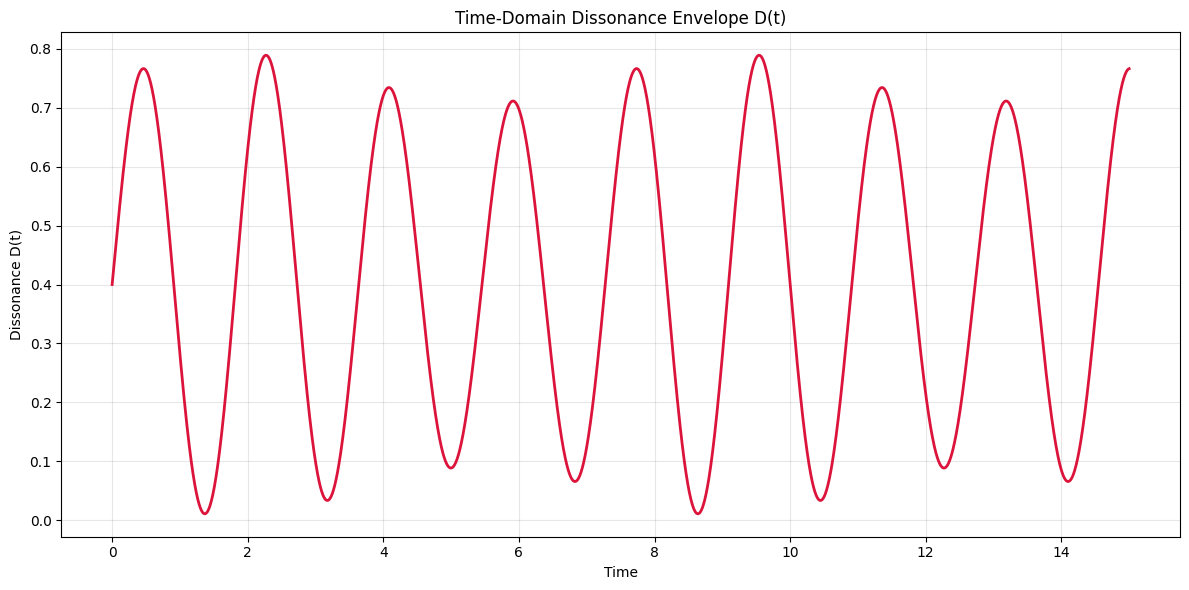

Saved to Drive: 29_dissonance_beta_coupling.png


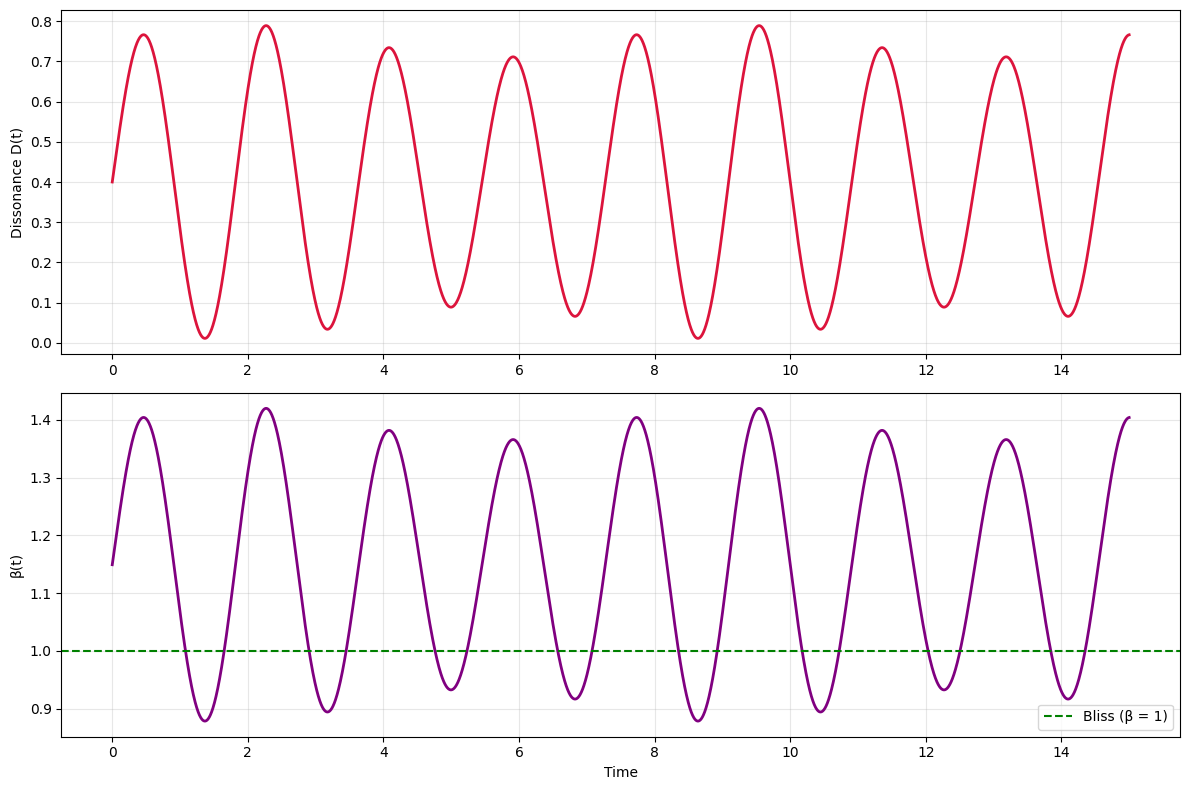

Saved to Drive: 30_dissonance_phase_portrait.png


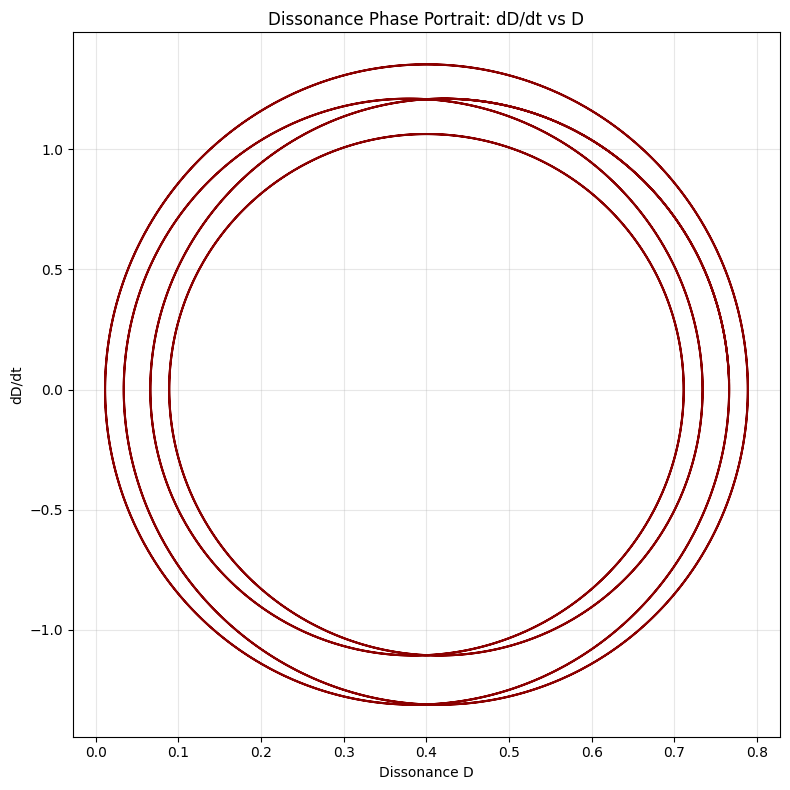

Saved to Drive: 31_dissonance_stability_map.png


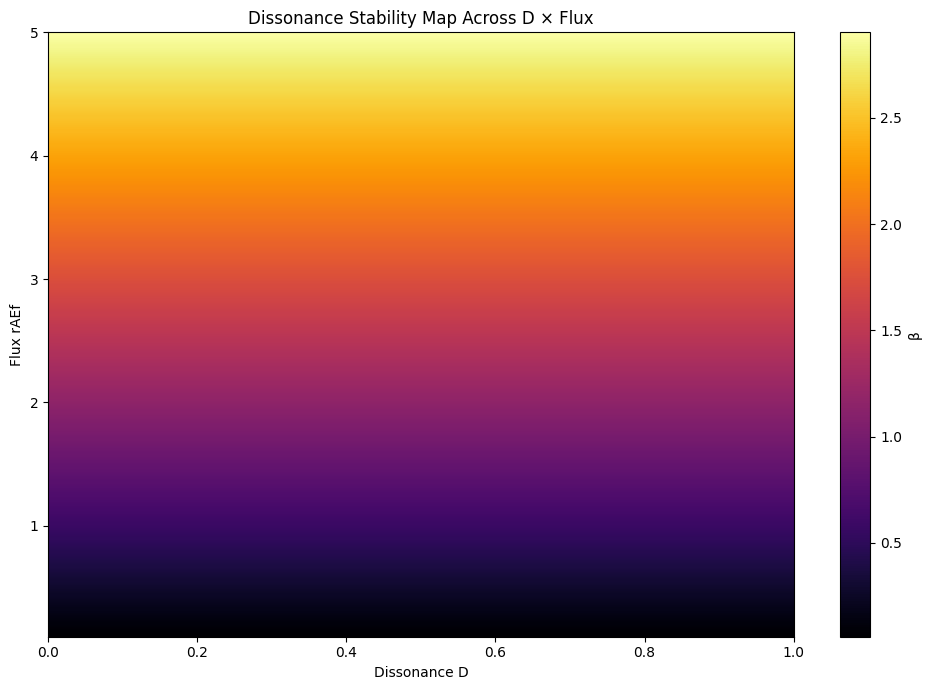

Saved to Drive: 32_dissonance_spectrum.png


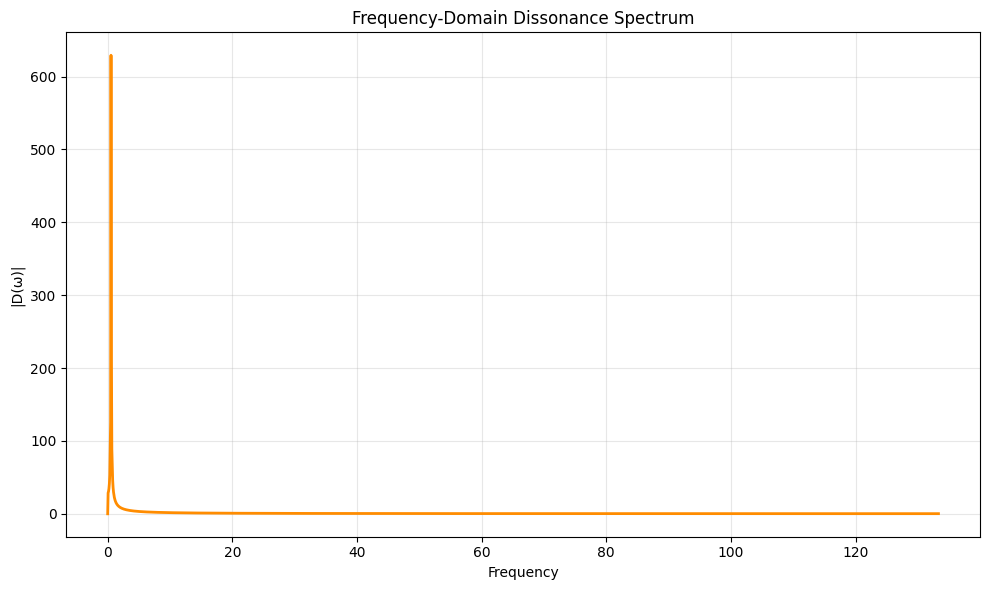

Done.


In [25]:
#!/usr/bin/env python3
# sim_dissonance_profile.py
# Auto-generated for VIM Thesis Simulation Suite

"""
Dissonance Profile Simulation

This module explores Harmonic Resonating Dissonance via:

1. Time-domain dissonance amplitude envelope D(t)
2. β coupling under dissonance-driven flux modulation
3. Dissonance phase portrait (dD/dt vs D)
4. Dissonance stability map across (D × rAEf)
5. Frequency-domain dissonance spectrum

Core relation:
    β = (rAEf * rAEc) / (rAEi * rAEt)

Dissonance acts as the vacuum-driving gradient ("Chaos").

All simulations are computational-only and safe.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PARAMETERS
# ---------------------------------------------------------

rAEc = 0.92
rAEi = 1.0
rAEt = 1.585

T = 15.0
N = 4000
t = np.linspace(0.0, T, N)
dt = t[1] - t[0]


# ---------------------------------------------------------
# CORE FUNCTIONS
# ---------------------------------------------------------

def beta(rAEf, rAEc, rAEi, rAEt):
    return (rAEf * rAEc) / (rAEi * rAEt)


def dissonance_profile(t, base=0.4, depth=0.35, freq=0.55, mod=0.12):
    """
    Harmonic Resonating Dissonance:
    A modulated sinusoid representing controlled topological instability.
    """
    carrier = depth * np.sin(2*np.pi*freq*t)
    envelope = 1 + mod * np.sin(2*np.pi*freq*0.25*t)
    return base + carrier * envelope


def flux_from_dissonance(D, base=1.5, gain=1.2):
    """
    Dissonance drives flux: rAEf = base + gain * D
    """
    return base + gain * D


# ---------------------------------------------------------
# SIM 1: TIME-DOMAIN DISSONANCE ENVELOPE
# ---------------------------------------------------------

def sim_dissonance_time_domain():
    D = dissonance_profile(t)
    plt.figure(figsize=(12, 6))
    plt.plot(t, D, color="crimson", linewidth=2)
    plt.title("Time-Domain Dissonance Envelope D(t)")
    plt.xlabel("Time")
    plt.ylabel("Dissonance D(t)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("28_dissonance_time_domain") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 2: β COUPLING UNDER DISSONANCE
# ---------------------------------------------------------

def sim_dissonance_beta_coupling():
    D = dissonance_profile(t)
    rAEf = flux_from_dissonance(D)
    beta_t = beta(rAEf, rAEc, rAEi, rAEt)

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    plt.plot(t, D, color="crimson", linewidth=2)
    plt.ylabel("Dissonance D(t)")
    plt.grid(alpha=0.3)

    plt.subplot(2, 1, 2)
    plt.plot(t, beta_t, color="purple", linewidth=2)
    plt.axhline(1.0, linestyle="--", color="green", label="Bliss (β = 1)")
    plt.ylabel("β(t)")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    quick_save("29_dissonance_beta_coupling") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 3: DISSONANCE PHASE PORTRAIT
# ---------------------------------------------------------

def sim_dissonance_phase_portrait():
    D = dissonance_profile(t)
    dD_dt = np.gradient(D, t)

    plt.figure(figsize=(8, 8))
    plt.plot(D, dD_dt, color="darkred", linewidth=1.5)
    plt.title("Dissonance Phase Portrait: dD/dt vs D")
    plt.xlabel("Dissonance D")
    plt.ylabel("dD/dt")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("30_dissonance_phase_portrait") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 4: DISSONANCE STABILITY MAP (D × rAEf)
# ---------------------------------------------------------

def sim_dissonance_stability_map():
    D_vals = np.linspace(0.0, 1.0, 300)
    F_vals = np.linspace(0.1, 5.0, 300)

    Dg, Fg = np.meshgrid(D_vals, F_vals)
    B = beta(Fg, rAEc, rAEi, rAEt)

    plt.figure(figsize=(10, 7))
    plt.imshow(B, extent=[0.0, 1.0, 0.1, 5.0], origin="lower",
               aspect="auto", cmap="inferno")
    plt.colorbar(label="β")
    plt.title("Dissonance Stability Map Across D × Flux")
    plt.xlabel("Dissonance D")
    plt.ylabel("Flux rAEf")
    plt.tight_layout()
    quick_save("31_dissonance_stability_map") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 5: FREQUENCY-DOMAIN DISSONANCE SPECTRUM
# ---------------------------------------------------------

def sim_dissonance_spectrum():
    D = dissonance_profile(t)
    D_centered = D - np.mean(D)

    spectrum = np.fft.rfft(D_centered)
    freqs = np.fft.rfftfreq(len(t), dt)
    mag = np.abs(spectrum)

    plt.figure(figsize=(10, 6))
    plt.plot(freqs, mag, color="darkorange", linewidth=2)
    plt.title("Frequency-Domain Dissonance Spectrum")
    plt.xlabel("Frequency")
    plt.ylabel("|D(ω)|")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("32_dissonance_spectrum") # Added save function
    plt.show()


# ---------------------------------------------------------
# MASTER RUNNER
# ---------------------------------------------------------

def run_simulation():
    print("Running Dissonance Profile simulations...")
    sim_dissonance_time_domain()
    sim_dissonance_beta_coupling()
    sim_dissonance_phase_portrait()
    sim_dissonance_stability_map()
    sim_dissonance_spectrum()
    print("Done.")


if __name__ == "__main__":
    run_simulation()


Running Control Loop Response simulations...
Saved to Drive: 33_control_loop_step_response.png


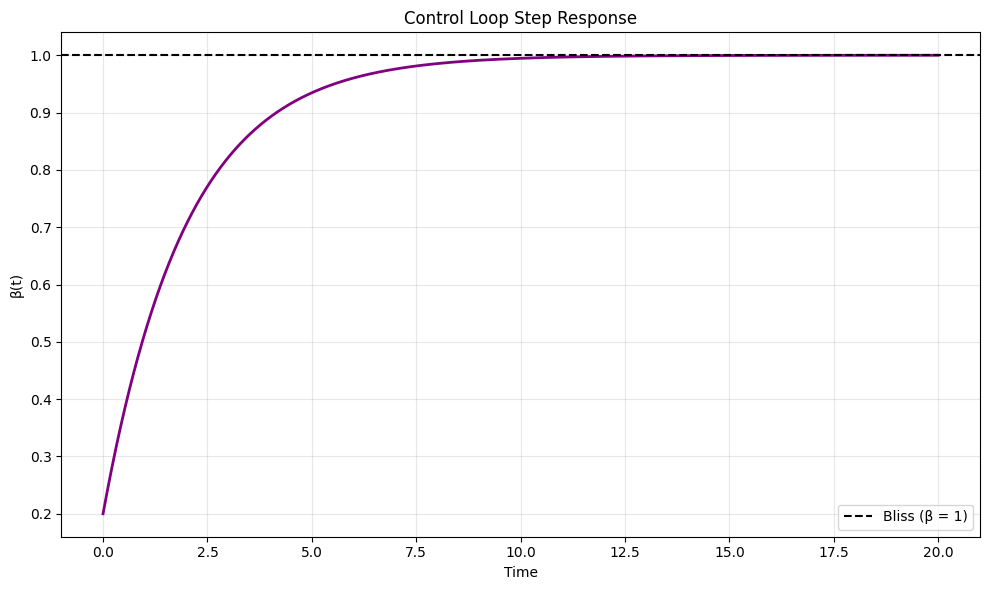

Saved to Drive: 34_control_loop_closed_vs_open.png


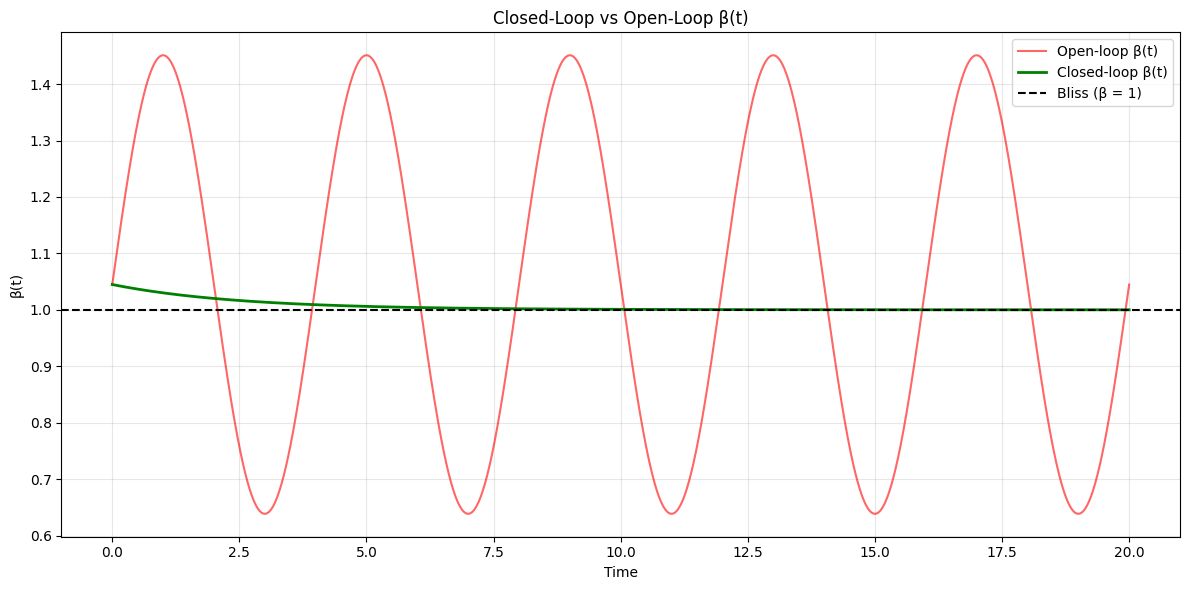

Saved to Drive: 35_control_loop_bode_magnitude.png


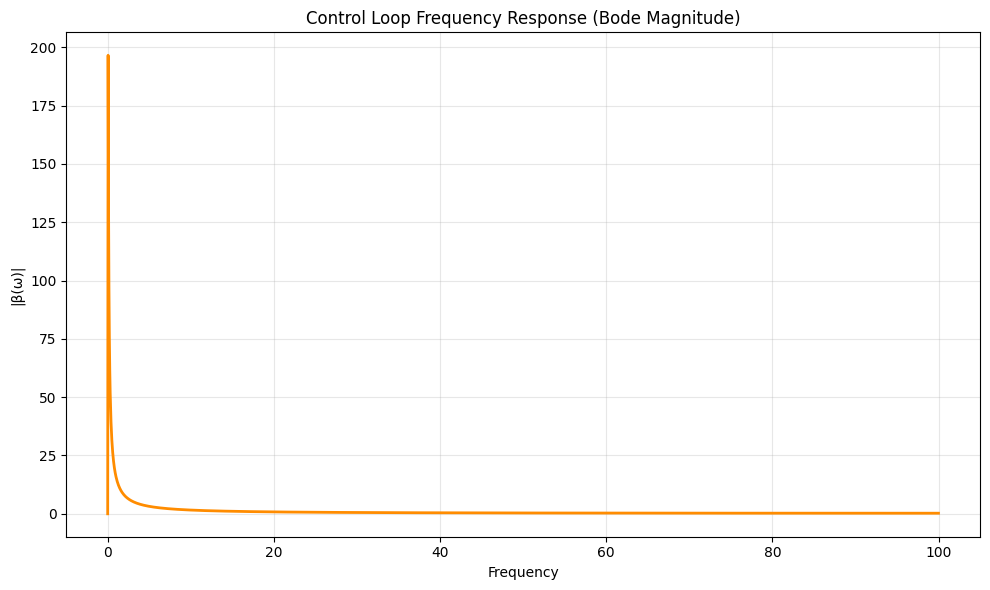

Saved to Drive: 36_control_loop_nyquist_curve.png


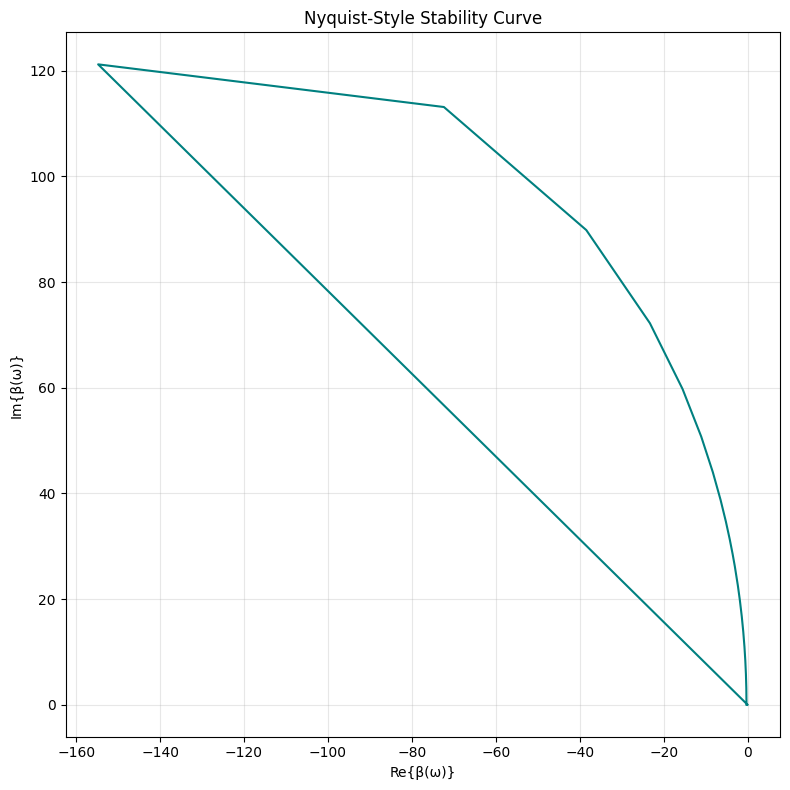

Saved to Drive: 37_control_loop_gain_sweep.png


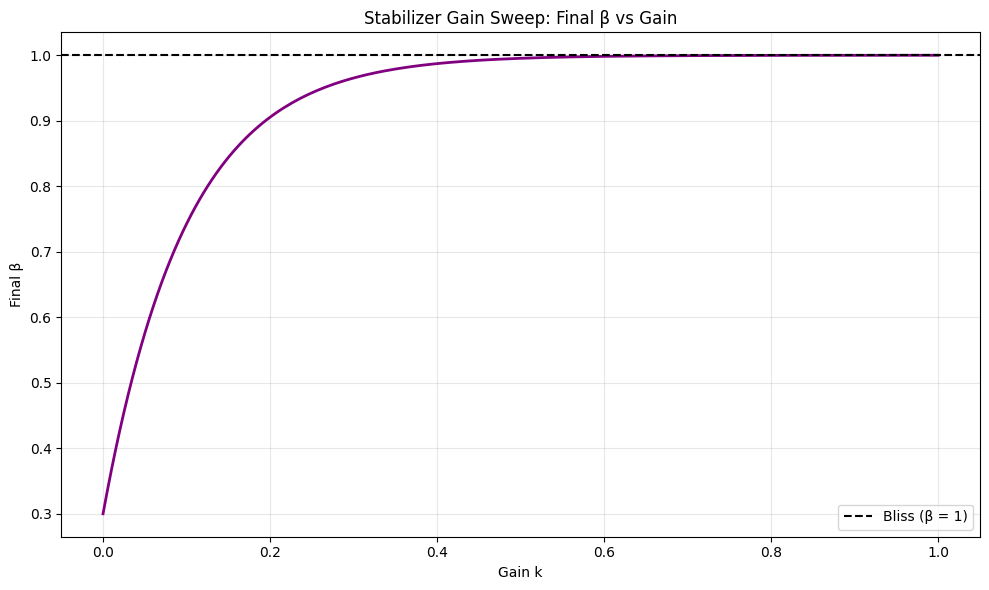

Done.


In [26]:
#!/usr/bin/env python3
# sim_control_loop_response.py
# Auto-generated for VIM Thesis Simulation Suite

"""
Control Loop Response Simulation

This module explores the VIM control loop via:

1. Step response of β(t) under stabilizer control
2. Closed-loop vs open-loop β(t)
3. Frequency response (Bode-style magnitude)
4. Nyquist-style stability curve
5. Gain sweep stability map

Core relation:
    β = (rAEf * rAEc) / (rAEi * rAEt)

All simulations are computational-only and safe.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PARAMETERS
# ---------------------------------------------------------

rAEc = 0.92
rAEi = 1.0
rAEt = 1.585

T = 20.0
N = 4000
t = np.linspace(0.0, T, N)
dt = t[1] - t[0]

B_TARGET = 1.0


# ---------------------------------------------------------
# CORE FUNCTIONS
# ---------------------------------------------------------

def beta(rAEf, rAEc, rAEi, rAEt):
    return (rAEf * rAEc) / (rAEi * rAEt)


def open_loop_flux(t, base=1.8, depth=0.7, freq=0.25):
    return base + depth * np.sin(2*np.pi*freq*t)


def stabilizer_step(beta_val, k=0.4):
    """
    Simple proportional controller:
    β_{n+1} = β_n + k * (1 - β_n) * dt
    """
    error = B_TARGET - beta_val
    return beta_val + k * error * dt


# ---------------------------------------------------------
# SIM 1: STEP RESPONSE
# ---------------------------------------------------------

def sim_step_response():
    beta_t = np.zeros_like(t)
    beta_t[0] = 0.2  # step from low β

    k = 0.5

    for i in range(1, len(t)):
        beta_t[i] = stabilizer_step(beta_t[i-1], k=k)

    plt.figure(figsize=(10, 6))
    plt.plot(t, beta_t, linewidth=2, color="purple")
    plt.axhline(1.0, linestyle="--", color="black", label="Bliss (β = 1)")
    plt.title("Control Loop Step Response")
    plt.xlabel("Time")
    plt.ylabel("β(t)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    quick_save("33_control_loop_step_response") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 2: CLOSED-LOOP VS OPEN-LOOP
# ---------------------------------------------------------

def sim_closed_vs_open():
    rAEf_ol = open_loop_flux(t)
    beta_ol = beta(rAEf_ol, rAEc, rAEi, rAEt)

    beta_cl = np.zeros_like(t)
    beta_cl[0] = beta_ol[0]

    k = 0.4

    for i in range(1, len(t)):
        beta_cl[i] = stabilizer_step(beta_cl[i-1], k=k)

    plt.figure(figsize=(12, 6))
    plt.plot(t, beta_ol, color="red", alpha=0.6, label="Open-loop β(t)")
    plt.plot(t, beta_cl, color="green", linewidth=2, label="Closed-loop β(t)")
    plt.axhline(1.0, linestyle="--", color="black", label="Bliss (β = 1)")
    plt.title("Closed-Loop vs Open-Loop β(t)")
    plt.xlabel("Time")
    plt.ylabel("β(t)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("34_control_loop_closed_vs_open") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 3: FREQUENCY RESPONSE (BODE MAGNITUDE)
# ---------------------------------------------------------

def sim_bode_magnitude():
    beta_t = np.zeros_like(t)
    beta_t[0] = 0.5

    k = 0.4

    for i in range(1, len(t)):
        beta_t[i] = stabilizer_step(beta_t[i-1], k=k)

    beta_centered = beta_t - np.mean(beta_t)
    spectrum = np.fft.rfft(beta_centered)
    freqs = np.fft.rfftfreq(len(t), dt)
    mag = np.abs(spectrum)

    plt.figure(figsize=(10, 6))
    plt.plot(freqs, mag, color="darkorange", linewidth=2)
    plt.title("Control Loop Frequency Response (Bode Magnitude)")
    plt.xlabel("Frequency")
    plt.ylabel("|β(ω)|")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("35_control_loop_bode_magnitude") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 4: NYQUIST-STYLE STABILITY CURVE
# ---------------------------------------------------------

def sim_nyquist_curve():
    beta_t = np.zeros_like(t)
    beta_t[0] = 0.5

    k = 0.4

    for i in range(1, len(t)):
        beta_t[i] = stabilizer_step(beta_t[i-1], k=k)

    beta_centered = beta_t - np.mean(beta_t)
    spectrum = np.fft.rfft(beta_centered)
    real = np.real(spectrum)
    imag = np.imag(spectrum)

    plt.figure(figsize=(8, 8))
    plt.plot(real, imag, color="teal", linewidth=1.5)
    plt.title("Nyquist-Style Stability Curve")
    plt.xlabel("Re{β(ω)}")
    plt.ylabel("Im{β(ω)}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("36_control_loop_nyquist_curve") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 5: GAIN SWEEP STABILITY MAP
# ---------------------------------------------------------

def sim_gain_sweep():
    gains = np.linspace(0.0, 1.0, 200)
    final_beta = np.zeros_like(gains)

    for idx, k in enumerate(gains):
        b = 0.3
        for _ in range(2000):
            b = stabilizer_step(b, k=k)
        final_beta[idx] = b

    plt.figure(figsize=(10, 6))
    plt.plot(gains, final_beta, color="purple", linewidth=2)
    plt.axhline(1.0, linestyle="--", color="black", label="Bliss (β = 1)")
    plt.title("Stabilizer Gain Sweep: Final β vs Gain")
    plt.xlabel("Gain k")
    plt.ylabel("Final β")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    quick_save("37_control_loop_gain_sweep") # Added save function
    plt.show()


# ---------------------------------------------------------
# MASTER RUNNER
# ---------------------------------------------------------

def run_simulation():
    print("Running Control Loop Response simulations...")
    sim_step_response()
    sim_closed_vs_open()
    sim_bode_magnitude()
    sim_nyquist_curve()
    sim_gain_sweep()
    print("Done.")


if __name__ == "__main__":
    run_simulation()


Running VIM Phase Space simulations...
Saved to Drive: 38_vim_phase_space_3d.png


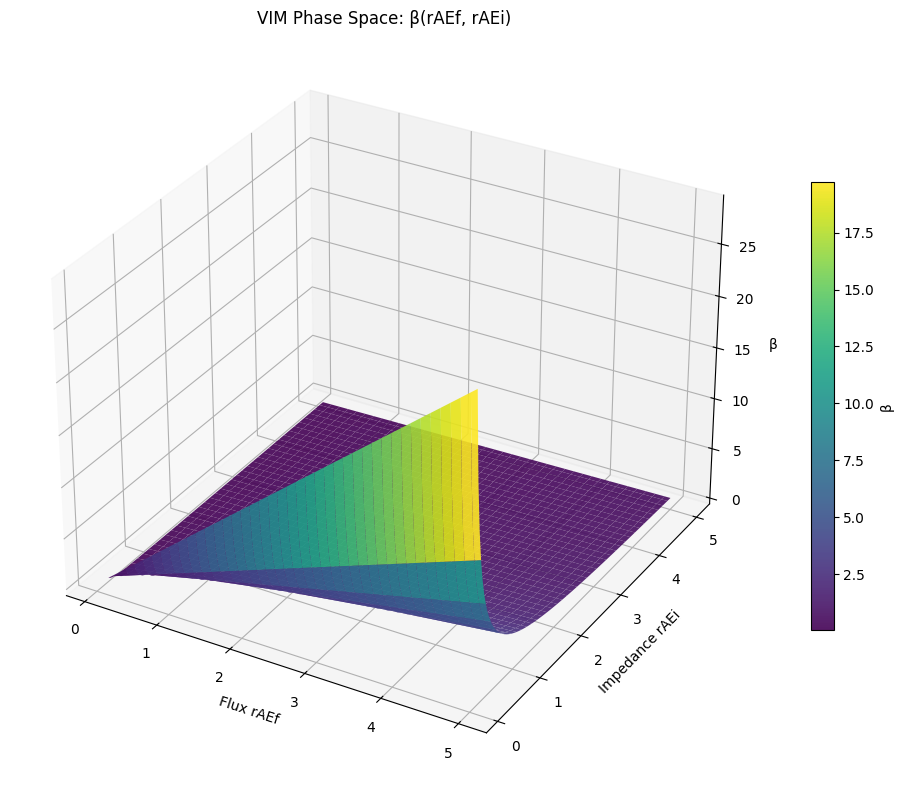

Saved to Drive: 39_vim_bliss_manifold.png


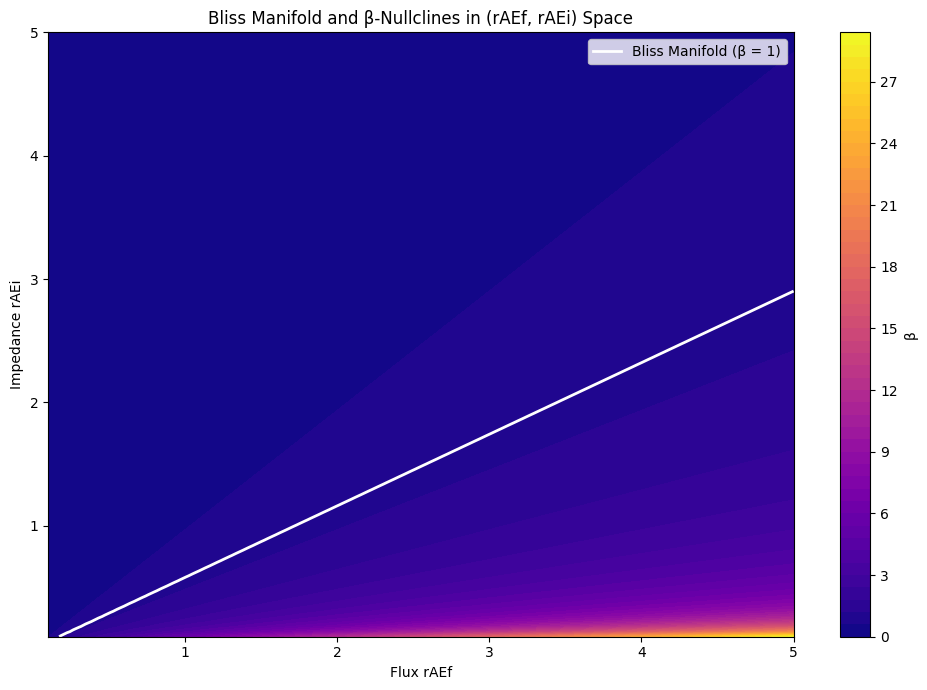

Saved to Drive: 40_vim_stability_basins.png


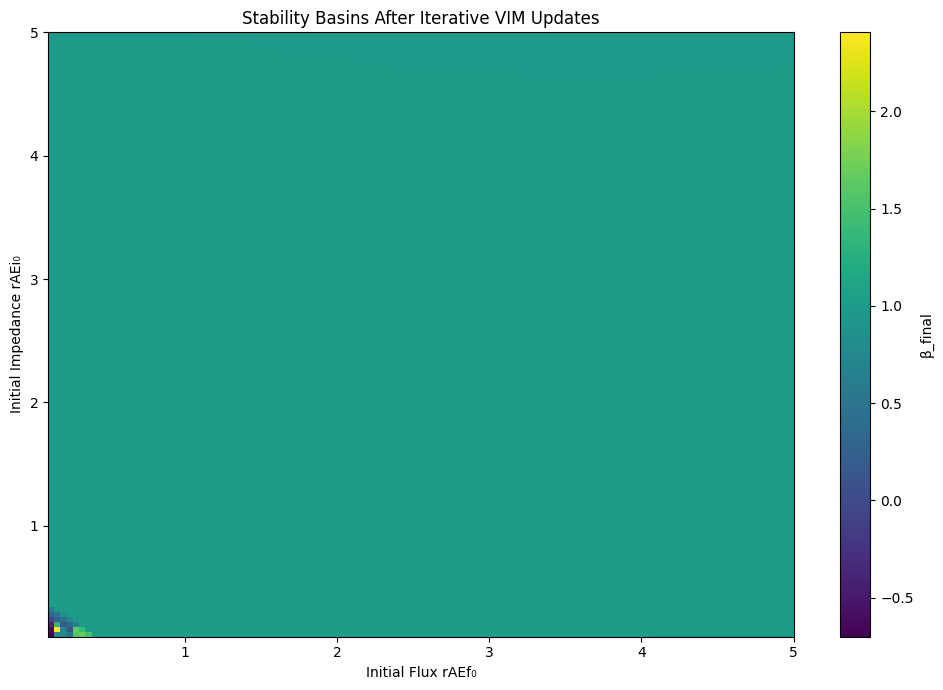

Saved to Drive: 41_vim_attractor_trajectories.png


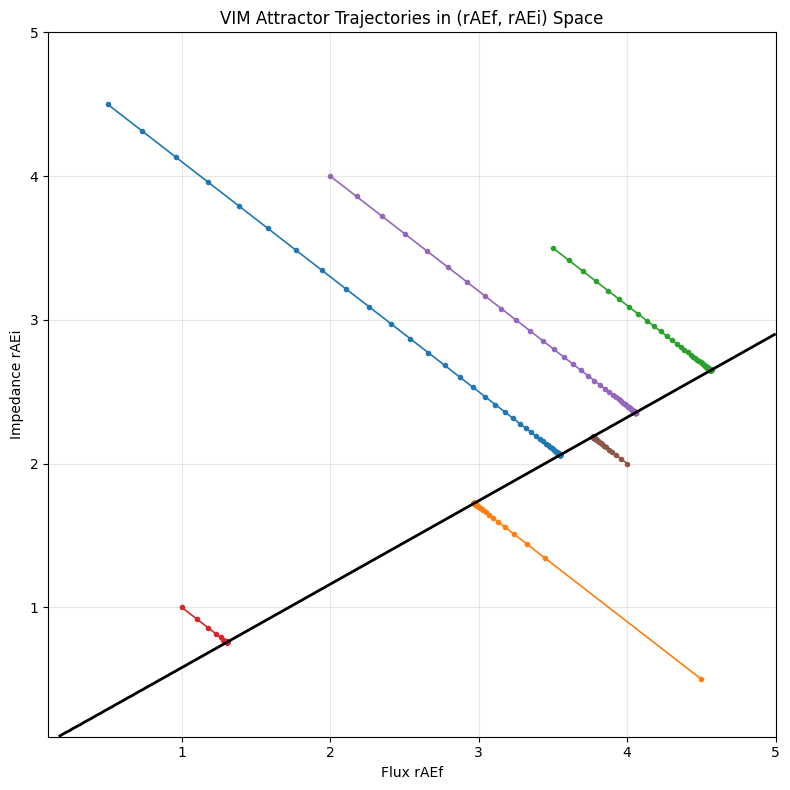

Done.


In [27]:
#!/usr/bin/env python3
# sim_vim_phase_space.py
# Auto-generated for VIM Thesis Simulation Suite

"""
VIM Phase Space Simulation

This module explores the full VIM phase space via:

1. 3D phase space: (rAEf, rAEi, β)
2. Bliss manifold and β-nullclines
3. Stability basins in (rAEf, rAEi) space
4. Attractor visualization for iterative VIM updates

Core relation:
    β = (rAEf * rAEc) / (rAEi * rAEt)

All simulations are computational-only and safe.
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---------------------------------------------------------
# PARAMETERS
# ---------------------------------------------------------

rAEc = 0.92
rAEt = 1.585

flux_range = np.linspace(0.1, 5.0, 120)
imp_range = np.linspace(0.1, 5.0, 120)


# ---------------------------------------------------------
# CORE FUNCTIONS
# ---------------------------------------------------------

def beta(rAEf, rAEc, rAEi, rAEt):
    return (rAEf * rAEc) / (rAEi * rAEt)


def vim_update_step(rAEf, rAEi, k_flux=0.25, k_imp=0.2):
    """
    Simple VIM update:
    Move (rAEf, rAEi) toward the Bliss manifold β = 1.
    """
    b = beta(rAEf, rAEc, rAEi, rAEt)
    error = 1.0 - b
    rAEf_new = rAEf + k_flux * error
    rAEi_new = rAEi - k_imp * error
    return rAEf_new, rAEi_new


# ---------------------------------------------------------
# SIM 1: 3D PHASE SPACE (rAEf, rAEi, β)
# ---------------------------------------------------------

def sim_phase_space_3d():
    F, I = np.meshgrid(flux_range, imp_range)
    B = beta(F, rAEc, I, rAEt)

    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(F, I, B, cmap="viridis", edgecolor="none", alpha=0.9)

    ax.set_title("VIM Phase Space: β(rAEf, rAEi)")
    ax.set_xlabel("Flux rAEf")
    ax.set_ylabel("Impedance rAEi")
    ax.set_zlabel("β")
    fig.colorbar(surf, shrink=0.6, label="β")

    plt.tight_layout()
    quick_save("38_vim_phase_space_3d") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 2: BLISS MANIFOLD & NULLCLINES
# ---------------------------------------------------------

def sim_bliss_manifold():
    F, I = np.meshgrid(flux_range, imp_range)
    B = beta(F, rAEc, I, rAEt)

    plt.figure(figsize=(10, 7))
    plt.contourf(F, I, B, levels=50, cmap="plasma")
    cbar = plt.colorbar()
    cbar.set_label("β")

    cs = plt.contour(F, I, B, levels=[1.0], colors="white", linewidths=2)

    # Proxy artist for legend (Colab-safe)
    import matplotlib.lines as mlines
    bliss_proxy = mlines.Line2D([], [], color="white", linewidth=2,
                                label="Bliss Manifold (β = 1)")
    plt.legend(handles=[bliss_proxy], loc="upper right")

    plt.title("Bliss Manifold and β-Nullclines in (rAEf, rAEi) Space")
    plt.xlabel("Flux rAEf")
    plt.ylabel("Impedance rAEi")
    plt.tight_layout()
    quick_save("39_vim_bliss_manifold") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 3: STABILITY BASINS (ITERATIVE VIM UPDATES)
# ---------------------------------------------------------

def sim_stability_basins():
    F0, I0 = np.meshgrid(flux_range, imp_range)
    F = F0.copy()
    I = I0.copy()

    for _ in range(40):
        F, I = vim_update_step(F, I, k_flux=0.25, k_imp=0.2)

    B_final = beta(F, rAEc, I, rAEt)

    plt.figure(figsize=(10, 7))
    plt.imshow(B_final,
               extent=[flux_range[0], flux_range[-1],
                       imp_range[0], imp_range[-1]],
               origin="lower", aspect="auto", cmap="viridis")
    plt.colorbar(label="β_final")
    plt.title("Stability Basins After Iterative VIM Updates")
    plt.xlabel("Initial Flux rAEf₀")
    plt.ylabel("Initial Impedance rAEi₀")
    plt.tight_layout()
    quick_save("40_vim_stability_basins") # Added save function
    plt.show()


# ---------------------------------------------------------
# SIM 4: ATTRACTOR TRAJECTORIES
# ---------------------------------------------------------

def sim_attractor_trajectories():
    initial_points = [
        (0.5, 4.5),
        (4.5, 0.5),
        (3.5, 3.5),
        (1.0, 1.0),
        (2.0, 4.0),
        (4.0, 2.0),
    ]

    plt.figure(figsize=(8, 8))

    for (f0, i0) in initial_points:
        traj_f = [f0]
        traj_i = [i0]

        f, i = f0, i0
        for _ in range(60):
            f, i = vim_update_step(f, i, k_flux=0.25, k_imp=0.2)
            traj_f.append(f)
            traj_i.append(i)

        plt.plot(traj_f, traj_i, "-o", markersize=3, linewidth=1.2)

    F, I = np.meshgrid(flux_range, imp_range)
    B = beta(F, rAEc, I, rAEt)
    plt.contour(F, I, B, levels=[1.0], colors="black", linewidths=2)

    plt.title("VIM Attractor Trajectories in (rAEf, rAEi) Space")
    plt.xlabel("Flux rAEf")
    plt.ylabel("Impedance rAEi")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    quick_save("41_vim_attractor_trajectories") # Added save function
    plt.show()


# ---------------------------------------------------------
# MASTER RUNNER
# ---------------------------------------------------------

def run_simulation():
    print("Running VIM Phase Space simulations...")
    sim_phase_space_3d()
    sim_bliss_manifold()
    sim_stability_basins()
    sim_attractor_trajectories()
    print("Done.")


if __name__ == "__main__":
    run_simulation()
